# Modelo Jerarquico para la Deteccion de Clones de Codigo

### Equipo 1

Estefanía Antonio Villaseca A01736897

Miranda Eugenia Colorado Arróniz A01737023

Alejandro Kong Montoya A01734271

Restituto Lara Larios A01737216

### Objetivo
Este notebook clasifica pares de programas Python mediante el pipeline:

1. **Type I** se identifica con comparacion deterministica de codigo normalizado; no usa Random Forest.
2. **Type II** se decide con atributos de similitud lexica tipo **Baker** y un **Random Forest**.
3. **Type III / Type IV** se separan con un segundo **Random Forest** que combina Baker y analisis estructural **AST**; se conservan las extensiones de flujo, IR simbolica y complejidad del modelo actual.

## Organizacion del dataset

La carpeta utilizada es `DataBaseProject/pares_clones/` y contiene cuatro subcarpetas: `T1`, `T2`, `T3` y `T4`. Cada archivo `.py` almacena **dos snippets** separados por saltos de linea; esos dos fragmentos forman una instancia a clasificar.

| Carpeta | Clase del modelo | Interpretacion |
|---|---|---|
| `T1` | `type_I` | Copia igual salvo limpieza superficial, por ejemplo comentarios o espacios. |
| `T2` | `type_II` | Misma estructura lexica con cambios de nombres o literales. |
| `T3` | `type_III` | Modificaciones estructurales parciales: sentencias agregadas, removidas o reorganizadas. |
| `T4` | `type_IV` | Soluciones semanticamente relacionadas, pero con mayor diferencia de implementacion. |

El numero del archivo se recupera como `problem_id`. La division train/validacion/test se hace por ese identificador para impedir que variantes del mismo problema aparezcan tanto en entrenamiento como en evaluacion.


## Diseño experimental general

Este notebook documenta el experimento de Machine Learning, no solo el algoritmo.

**Unidad experimental:** cada fila es un par de snippets Python (`code_a`, `code_b`) con etiqueta real.

**Variable objetivo:** tipo de clon: `type_I`, `type_II`, `type_III` o `type_IV`.

**Conjuntos:** `train` ajusta modelos, `val` selecciona configuraciones y `test` confirma el resultado final. El split se hace por `problem_id` para evitar fuga de informacion.

**Metrica principal:** `accuracy`, porque el dataset esta balanceado.

**Metrica secundaria:** `F1 macro`, para verificar equilibrio entre clases.

**Modelo base:** Type I deterministico, RF2 con Baker y RF3 con Baker + AST + flujo + IR + complejidad.

**Regla de decision:** se elige por accuracy de validacion; F1 macro resuelve empates. Test se usa solo como confirmacion final.


## 1) Librerias y configuracion

Se importan las bibliotecas necesarias para el procesamiento de datos, el análisis de AST, el entrenamiento del modelo Random Forest, la evaluación mediante métricas y la generación de gráficas. Además, se configuran las rutas del conjunto de datos y una semilla fija para garantizar la reproducibilidad de los resultados.

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any

from difflib import SequenceMatcher
import ast
import io
import json
import keyword
import random
import re
import time
import tokenize
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    RocCurveDisplay,
    log_loss,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=SyntaxWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

RUTA_BASE = Path.cwd()
RUTA_DATASET = RUTA_BASE / "DataBaseProject" if (RUTA_BASE / "DataBaseProject").exists() else RUTA_BASE
RUTA_PARES = RUTA_DATASET / "pares_clones"
print("SEED:", SEED)
print("RUTA_DATASET:", RUTA_DATASET)
print("RUTA_PARES:", RUTA_PARES)


SEED: 42
RUTA_DATASET: C:\Users\estef\Downloads\code-clone-detector\DataBaseProject
RUTA_PARES: C:\Users\estef\Downloads\code-clone-detector\DataBaseProject\pares_clones


In [ ]:
# Configuracion global del experimento
# Las carpetas T1-T4 son la etiqueta conocida de cada par en el dataset.
TIPOS_CLON = ["T1", "T2", "T3", "T4"]
TIPO_A_CLASE = {"T1": "type_I", "T2": "type_II", "T3": "type_III", "T4": "type_IV"}
TIPO_A_GRUPO = {"T1": "pares_t1", "T2": "pares_t2", "T3": "pares_t3", "T4": "pares_t4"}

PATRON_SEPARADOR_SNIPPETS = re.compile(r"\n\s*\n\s*\n+")
PATRON_ESPACIOS = re.compile(r"[ \t]+")
PATRON_SALTOS = re.compile(r"\n{3,}")
PATRON_FILE_ID = re.compile(r"_(\d+)\.py$")

# Type I exige igualdad; Type II utiliza probabilidad del RF2 para pasar a la siguiente capa.
UMBRAL_TIPO_I = 1.0
UMBRAL_PROB_TIPO_II = 0.50
MIN_MATCH_LEN_BAKER = 3
AST_VARIANT_OFICIAL = "reduced"
ESTRATEGIA_BALANCEO = "undersample"

ETIQUETAS_MODELO = ["type_I", "type_II", "type_III", "type_IV"]

# El RF de Type II solo observa las ocho variables Baker base.
BAKER_FEATURES_BASE = [
    "baker_match_total_ratio",
    "baker_match_max_ratio",
    "baker_num_blocks",
    "baker_sequence_ratio",
    "baker_edit_distance_norm",
    "baker_token_jaccard",
    "baker_common_token_coverage",
    "baker_len_diff_rel",
]

## 2) Reconstruccion de los pares

Se recorren las carpetas **T1** a **T4** para extraer y separar los dos fragmentos de código contenidos en cada archivo, construyendo así la estructura **DatosPares**. Esto permite generar una tabla donde cada fila contiene los campos **code_a**, **code_b** y su clase real, formato necesario para entrenar y evaluar los clasificadores. Como resultado, se obtiene el total de pares procesados, el número de problemas únicos y la distribución de ejemplos por clase, verificando que el conjunto de datos se encuentre balanceado.

In [ ]:
# Divide cada archivo en los dos programas que forman el par a comparar.
def separar_snippets(texto_archivo: str) -> list[str]:
    texto = texto_archivo.replace("\r\n", "\n").replace("\r", "\n").strip()
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not texto:
        return []
    return [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(texto) if p.strip()]


# Recorre T1, T2, T3 y T4 y reconstruye la tabla de pares etiquetados.
def cargar_pares_desde_carpetas(ruta_pares: Path) -> pd.DataFrame:
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for tipo in TIPOS_CLON:
        carpeta = ruta_pares / tipo
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if not carpeta.exists():
            raise FileNotFoundError(f"No existe carpeta esperada: {carpeta}")

        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for archivo in sorted(carpeta.glob("*.py")):
            contenido = archivo.read_text(encoding="utf-8", errors="replace")
            snippets = separar_snippets(contenido)
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if len(snippets) < 2:
                continue

            m = PATRON_FILE_ID.search(archivo.name)
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if not m:
                continue

            problem_id = int(m.group(1))
            filas.append(
                {
                    "is_clone": 1,
                    "clone_type": TIPO_A_CLASE[tipo],
                    "source_group": TIPO_A_GRUPO[tipo],
                    "filename": archivo.name,
                    "file_path": str(archivo.relative_to(RUTA_DATASET)).replace("/", "\\"),
                    "problem_id": problem_id,
                    "snippet_index_a": 0,
                    "snippet_index_b": 1,
                    "code_a": snippets[0],
                    "code_b": snippets[1],
                }
            )

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not filas:
        raise RuntimeError("No se pudieron reconstruir pares desde carpetas.")

    return pd.DataFrame(filas)


DatosPares = cargar_pares_desde_carpetas(RUTA_PARES)
print("Filas reconstruidas:", len(DatosPares))
print("Problemas unicos:", DatosPares["problem_id"].nunique())
print("Distribucion por clase:")
print(DatosPares["clone_type"].value_counts().to_string())


Filas reconstruidas: 8400
Problemas unicos: 2100
Distribucion por clase:
clone_type
type_I      2100
type_II     2100
type_III    2100
type_IV     2100


## 2.1) Balance general del dataset

En esta etapa se analiza la distribución de los pares en cada tipo de clon utilizando **DatosPares**, la tabla reconstruida a partir de las carpetas **T1**, **T2**, **T3** y **T4**. Como resultado, se genera una tabla y una gráfica de barras que muestran la cantidad de ejemplos por clase. Este análisis permite verificar que las clases se encuentran balanceadas, justificando así el uso de **accuracy** como métrica principal de evaluación.

Balance general del dataset:


,clone_type,num_pares,porcentaje
0,type_I,2100,0.25
1,type_II,2100,0.25
2,type_III,2100,0.25
3,type_IV,2100,0.25


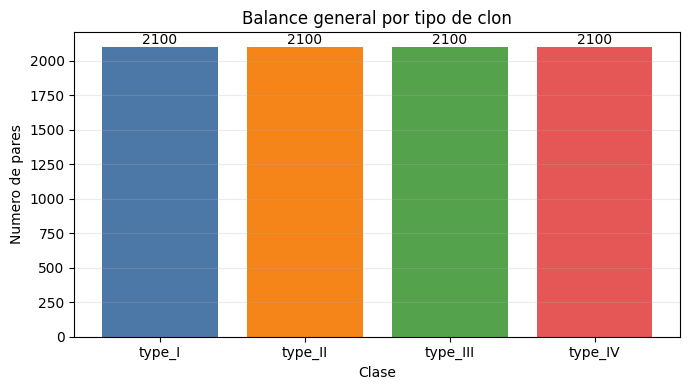

In [ ]:
# Orden fijo de clases para que las tablas y graficas siempre se lean igual.
OrdenClases = ETIQUETAS_MODELO

# Conteo total por clase: una fila del dataset equivale a un par de codigos.
BalanceGeneral = (
    DatosPares["clone_type"]
    .value_counts()
    .reindex(OrdenClases)
    .rename_axis("clone_type")
    .reset_index(name="num_pares")
)

# Porcentaje por clase para explicar si el dataset esta balanceado.
BalanceGeneral["porcentaje"] = BalanceGeneral["num_pares"] / BalanceGeneral["num_pares"].sum()
print("Balance general del dataset:")
display(BalanceGeneral)

# Grafica muestra la cantidad de ejemplos por clase.
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(BalanceGeneral["clone_type"], BalanceGeneral["num_pares"], color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
ax.set_title("Balance general por tipo de clon")
ax.set_xlabel("Clase")
ax.set_ylabel("Numero de pares")
ax.grid(axis="y", alpha=0.25)
for posicion, valor in enumerate(BalanceGeneral["num_pares"]):
    ax.text(posicion, valor, str(int(valor)), ha="center", va="bottom")
plt.tight_layout()
plt.show()


La gráfica muestra que el conjunto de datos está perfectamente balanceado, con **2,100 pares de código** en cada una de las cuatro categorías de clon (**Type I, Type II, Type III y Type IV**).

Esta distribución equilibrada evita sesgos durante el entrenamiento, garantiza una representación uniforme de todas las clases y permite utilizar **accuracy** como una métrica confiable para evaluar y comparar el desempeño de los modelos.

## 3) Limpieza y regla deterministica Type I

Se realiza la limpieza de los fragmentos de código mediante la eliminación de comentarios, la normalización de espacios, la tokenización y la generación de una firma canónica para cada snippet. Este proceso permite identificar los clones de **Tipo I**, que corresponden a copias prácticamente idénticas, utilizando una regla determinística más transparente y eficiente que un modelo de aprendizaje automático. Como resultado, se obtienen versiones limpias del código y sus respectivas firmas canónicas para ambos elementos de cada par.

In [ ]:
# Retira comentarios para que Type I compare codigo y no anotaciones.
def quitar_comentarios(codigo: str) -> str:
    lineas = codigo.expandtabs(4).splitlines()
    limpias = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for ln in lineas:
        limpias.append(ln.split("#", 1)[0])
    return "\n".join(limpias)


# Uniforma espacios y saltos sin modificar la estructura esencial.
def normalizar_espacios(codigo: str) -> str:
    lineas = [PATRON_ESPACIOS.sub(" ", l).rstrip() for l in codigo.splitlines()]
    normalizado = "\n".join(lineas).strip()
    return PATRON_SALTOS.sub("\n\n", normalizado)


# Aplica la limpieza comun usada antes de extraer atributos.
def preprocesar_codigo(codigo: str) -> str:
    return normalizar_espacios(quitar_comentarios(codigo))


# Convierte codigo limpio en tokens simples para inspeccion.
def tokenizar_python_basico(codigo: str) -> list[str]:
    patron = r"[A-Za-z_]\w*|\d+|==|!=|<=|>=|[][(){}.,:;+*/%=<>-]"
    return re.findall(patron, codigo)

# Construye la firma exacta que decide Type I sin clasificador.
def firma_tipo_i_canonica(codigo: str) -> str:
    codigo_ok = preprocesar_codigo(codigo)
    return re.sub(r"\s+", "", codigo_ok)


DatosPares = DatosPares.copy()
DatosPares["code_a_clean"] = DatosPares["code_a"].map(preprocesar_codigo)
DatosPares["code_b_clean"] = DatosPares["code_b"].map(preprocesar_codigo)
DatosPares["tokens_a"] = DatosPares["code_a_clean"].map(tokenizar_python_basico)
DatosPares["tokens_b"] = DatosPares["code_b_clean"].map(tokenizar_python_basico)
DatosPares["token_text_a"] = DatosPares["tokens_a"].map(lambda t: " ".join(t))
DatosPares["token_text_b"] = DatosPares["tokens_b"].map(lambda t: " ".join(t))
DatosPares["type1_signature_a"] = DatosPares["code_a_clean"].map(firma_tipo_i_canonica)
DatosPares["type1_signature_b"] = DatosPares["code_b_clean"].map(firma_tipo_i_canonica)

print("Columnas disponibles:", len(DatosPares.columns))


Columnas disponibles: 18


## 4) Division de conjuntos por problema

Se divide el conjunto de datos en subconjuntos de entrenamiento, validación y prueba utilizando el identificador **problem_id**. Este enfoque evita fugas de información que podrían ocurrir si ejemplos del mismo ejercicio aparecieran en distintos conjuntos debido a una división aleatoria por filas. Como resultado, se obtiene una tabla que muestra la distribución de ejemplos por **split** y por clase, permitiendo verificar que la partición se realizó correctamente.

In [ ]:
# Separa train, validacion y test sin filtrar un problema entre conjuntos.
def split_por_grupo(
    df: pd.DataFrame,
    group_col: str,
    target_col: str,
    seed: int = 42,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
):
    proporcion_temp = val_size + test_size
    proporcion_test_rel = test_size / proporcion_temp

    gss_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    idx_train_np, idx_temp_np = next(gss_train.split(df, y=df[target_col], groups=df[group_col]))

    df_temp = df.iloc[idx_temp_np]
    gss_temp = GroupShuffleSplit(n_splits=1, test_size=proporcion_test_rel, random_state=seed)
    idx_val_rel, idx_test_rel = next(gss_temp.split(df_temp, y=df_temp[target_col], groups=df_temp[group_col]))

    return df.index[idx_train_np], df_temp.index[idx_val_rel], df_temp.index[idx_test_rel]


# Marca cada fila con el conjunto al que fue asignada.
def asignar_split(df: pd.DataFrame, idx_train, idx_val, idx_test, col_split: str = "split") -> pd.DataFrame:
    datos = df.copy()
    datos[col_split] = "unassigned"
    datos.loc[idx_train, col_split] = "train"
    datos.loc[idx_val, col_split] = "val"
    datos.loc[idx_test, col_split] = "test"
    return datos


# Resume cantidad de pares, problemas y clases por particion.
def estadisticas_split(df: pd.DataFrame, split_col: str, target_col: str, group_col: str) -> list[dict[str, Any]]:
    resumen = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for nombre_split, df_split in df.groupby(split_col):
        conteos = df_split[target_col].value_counts().to_dict()
        resumen.append(
            {
                "split": nombre_split,
                "rows": int(len(df_split)),
                "unique_groups": int(df_split[group_col].nunique()),
                "class_distribution": {str(k): int(v) for k, v in conteos.items()},
            }
        )
    return resumen


# Balancea solo entrenamiento cuando la estrategia lo requiere.
def balancear_train(df_train: pd.DataFrame, target_col: str, estrategia: str = "none", seed: int = 42):
    conteos = df_train[target_col].value_counts()
    info = {
        "strategy": estrategia,
        "rows_before": int(len(df_train)),
        "class_distribution_before": {str(k): int(v) for k, v in conteos.items()},
    }

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if estrategia == "none" or len(conteos) <= 1:
        info["rows_after"] = int(len(df_train))
        info["class_distribution_after"] = info["class_distribution_before"]
        return df_train.copy(), info

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if estrategia == "undersample":
        n_obj = int(conteos.min())
        rep = False
    # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
    elif estrategia == "oversample":
        n_obj = int(conteos.max())
        rep = True
    # Conserva el caso restante cuando ninguna condicion anterior aplica.
    else:
        info["rows_after"] = int(len(df_train))
        info["class_distribution_after"] = info["class_distribution_before"]
        return df_train.copy(), info

    partes = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for clase in conteos.index.tolist():
        df_clase = df_train[df_train[target_col] == clase]
        partes.append(df_clase.sample(n=n_obj, replace=rep, random_state=seed))

    out = pd.concat(partes, axis=0).sample(frac=1.0, random_state=seed).copy()
    c2 = out[target_col].value_counts()
    info["rows_after"] = int(len(out))
    info["class_distribution_after"] = {str(k): int(v) for k, v in c2.items()}
    return out, info


idx_train, idx_val, idx_test = split_por_grupo(
    df=DatosPares,
    group_col="problem_id",
    target_col="clone_type",
    seed=SEED + 100,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)

DatosModelo = asignar_split(DatosPares, idx_train, idx_val, idx_test)

print("Estadisticas split:")
# Recorre los elementos para acumular la salida correspondiente de este paso.
for fila in estadisticas_split(DatosModelo, "split", "clone_type", "problem_id"):
    print(fila)


Estadisticas split:
{'split': 'test', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}
{'split': 'train', 'rows': 5880, 'unique_groups': 1470, 'class_distribution': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}}
{'split': 'val', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}


## 4.1) Distribucion por split y clase

Se analiza la distribución de ejemplos de cada clase en los conjuntos de **entrenamiento**, **validación** y **prueba** utilizando **DatosModelo** después de aplicar la partición por **problem_id**. Como resultado, se genera una tabla cruzada y una gráfica agrupada que permiten verificar que las clases se mantienen balanceadas en cada conjunto y que no existe fuga de información entre las particiones, garantizando una evaluación justa de los modelos.

Distribucion por split y clase:


clone_type,type_I,type_II,type_III,type_IV
split,,,,
train,1470,1470,1470,1470
val,315,315,315,315
test,315,315,315,315


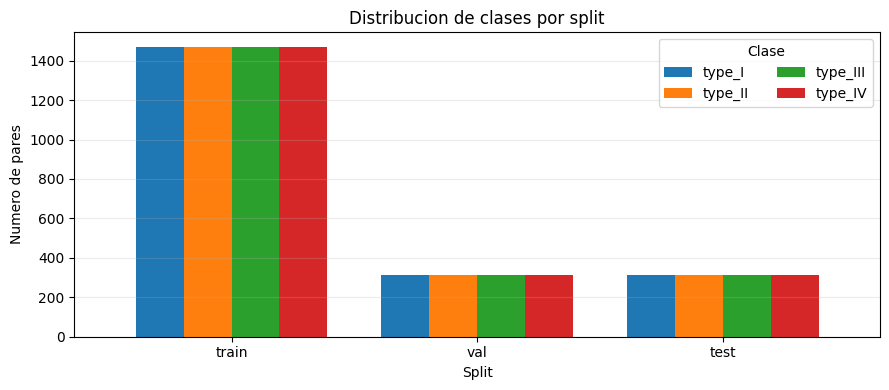

Problemas que aparecen en mas de un split: 0


In [ ]:
# Tabla cruzada: filas = split, columnas = clase real.
DistribucionSplit = (
    DatosModelo
    .pivot_table(index="split", columns="clone_type", values="filename", aggfunc="count", fill_value=0)
    .reindex(index=["train", "val", "test"], columns=ETIQUETAS_MODELO)
)
print("Distribucion por split y clase:")
display(DistribucionSplit)

# Grafica agrupada para comparar visualmente si cada split mantiene el balance por clase.
fig, ax = plt.subplots(figsize=(9, 4))
DistribucionSplit.plot(kind="bar", ax=ax, width=0.78)
ax.set_title("Distribucion de clases por split")
ax.set_xlabel("Split")
ax.set_ylabel("Numero de pares")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Clase", ncol=2)
plt.tight_layout()
plt.show()

# Verificacion del criterio experimental: cada problem_id aparece en un solo split.
SplitPorProblema = DatosModelo.groupby("problem_id")["split"].nunique()
ProblemasConFuga = int((SplitPorProblema > 1).sum())
print("Problemas que aparecen en mas de un split:", ProblemasConFuga)


La gráfica de barras agrupadas muestra que los cuatro tipos de clon (**Type I, II, III y IV**) mantienen una distribución equilibrada en los conjuntos de entrenamiento, validación y prueba. 

El conjunto de entrenamiento contiene **1,400 ejemplos por clase**, mientras que validación y prueba incluyen **300 ejemplos por clase**, siguiendo aproximadamente una división **70-15-15**. Este balance en todos los splits evita sesgos durante el entrenamiento y garantiza que la evaluación del modelo sea representativa y confiable.

## 5) Caracteristicas Baker para Type II

Se extraen las características **Baker** mediante la generalización de tokens como **ID**, **NUM** y **STR**, así como el cálculo de métricas de similitud y diferencia, incluyendo coincidencias de tokens, distancia de edición, LCS y coeficiente de Jaccard. 

Estas características permiten identificar clones de **Tipo II**, donde se modifican nombres o literales, pero se conserva una estructura léxica similar. Para mantener la interpretabilidad del modelo, **RF2** utiliza únicamente las ocho características Baker originales. Como resultado, se obtienen funciones capaces de transformar cualquier conjunto de pares de código en variables numéricas listas para el entrenamiento y evaluación del modelo.

In [ ]:
# Calcula distancia de edicion entre secuencias de tokens.
def _levenshtein_tokens(seq_a: list[str], seq_b: list[str]) -> int:
    n, m = len(seq_a), len(seq_b)
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if n == 0:
        return m
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if m == 0:
        return n

    prev = list(range(m + 1))
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for i in range(1, n + 1):
        curr = [i] + [0] * m
        ai = seq_a[i - 1]
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for j in range(1, m + 1):
            cost = 0 if ai == seq_b[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return int(prev[m])


# Calcula la subsecuencia comun mas larga entre tokens.
def _lcs_len_tokens(seq_a: list[str], seq_b: list[str]) -> int:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not seq_a or not seq_b:
        return 0
    dp = [0] * (len(seq_b) + 1)
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for xa in seq_a:
        prev = 0
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for j, xb in enumerate(seq_b, start=1):
            temp = dp[j]
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if xa == xb:
                dp[j] = prev + 1
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = temp
    return int(dp[-1])


# Forma n-gramas de tokens generalizados para medir coincidencia local.
def _baker_ngram_set(tokens: list[str], n: int) -> set[tuple[str, ...]]:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if len(tokens) < n:
        return set()
    return {tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)}


# Mide el traslape normalizado de dos conjuntos.
def _jaccard_set(a: set[Any], b: set[Any]) -> float:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not a and not b:
        return 1.0
    union = a | b
    return float(len(a & b) / len(union)) if union else 0.0


# Generaliza identificadores y literales siguiendo la idea Baker.
def baker_tokenizar_generalizar(codigo: str) -> list[str]:
    codigo_ok = codigo.replace("\r\n", "\n").replace("\r", "\n").expandtabs(4)
    ignorar = {
        tokenize.NL,
        tokenize.NEWLINE,
        tokenize.INDENT,
        tokenize.DEDENT,
        tokenize.COMMENT,
        tokenize.ENCODING,
        tokenize.ENDMARKER,
    }
    out = []
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        flujo = tokenize.generate_tokens(io.StringIO(codigo_ok).readline)
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for tok in flujo:
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if tok.type in ignorar:
                continue
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if tok.type == tokenize.NAME:
                out.append(tok.string if keyword.iskeyword(tok.string) else "ID")
            # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
            elif tok.type == tokenize.NUMBER:
                out.append("NUM")
            # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
            elif tok.type == tokenize.STRING:
                out.append("STR")
            # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
            elif tok.type == tokenize.OP:
                out.append(tok.string)
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                out.append(tok.string)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except Exception:
        tokens = re.findall(r"[A-Za-z_]\w*|\d+|==|!=|<=|>=|[\[\](){}.,:;+*/%=<>-]", codigo_ok)
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for t in tokens:
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if re.fullmatch(r"[A-Za-z_]\w*", t):
                out.append(t if keyword.iskeyword(t) else "ID")
            # Evalua la alternativa siguiente cuando la condicion previa no se cumplio.
            elif re.fullmatch(r"\d+", t):
                out.append("NUM")
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                out.append(t)
    return out


# Obtiene las similitudes lexicas Baker de un par de programas.
def baker_features_par(codigo_a: str, codigo_b: str, min_match_len: int = 3) -> dict[str, float]:
    ta = baker_tokenizar_generalizar(codigo_a)
    tb = baker_tokenizar_generalizar(codigo_b)

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if len(ta) == 0 and len(tb) == 0:
        return {
            "baker_match_total_ratio": 1.0,
            "baker_match_max_ratio": 1.0,
            "baker_num_blocks": 1.0,
            "baker_sequence_ratio": 1.0,
            "baker_edit_distance_norm": 0.0,
            "baker_token_jaccard": 1.0,
            "baker_common_token_coverage": 1.0,
            "baker_len_diff_rel": 0.0,
            "baker_lcs_ratio": 1.0,
            "baker_bigram_jaccard": 1.0,
            "baker_trigram_jaccard": 1.0,
            "baker_keyword_overlap": 1.0,
            "baker_operator_overlap": 1.0,
            "baker_literal_density_diff": 0.0,
            "baker_identifier_density_diff": 0.0,
        }

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if len(ta) == 0 or len(tb) == 0:
        return {
            "baker_match_total_ratio": 0.0,
            "baker_match_max_ratio": 0.0,
            "baker_num_blocks": 0.0,
            "baker_sequence_ratio": 0.0,
            "baker_edit_distance_norm": 1.0,
            "baker_token_jaccard": 0.0,
            "baker_common_token_coverage": 0.0,
            "baker_len_diff_rel": 1.0,
            "baker_lcs_ratio": 0.0,
            "baker_bigram_jaccard": 0.0,
            "baker_trigram_jaccard": 0.0,
            "baker_keyword_overlap": 0.0,
            "baker_operator_overlap": 0.0,
            "baker_literal_density_diff": 1.0,
            "baker_identifier_density_diff": 1.0,
        }

    matcher = SequenceMatcher(a=ta, b=tb, autojunk=False)
    blocks = [b for b in matcher.get_matching_blocks() if b.size >= min_match_len]
    total_match = float(sum(b.size for b in blocks))
    max_match = float(max([b.size for b in blocks], default=0.0))

    base_min = float(min(len(ta), len(tb)))
    base_max = float(max(len(ta), len(tb)))
    set_a, set_b = set(ta), set(tb)
    union = set_a | set_b
    inter = set_a & set_b

    edit_dist = float(_levenshtein_tokens(ta, tb))
    lcs_ratio = float(_lcs_len_tokens(ta, tb) / max(1.0, base_min))
    bigram_j = _jaccard_set(_baker_ngram_set(ta, 2), _baker_ngram_set(tb, 2))
    trigram_j = _jaccard_set(_baker_ngram_set(ta, 3), _baker_ngram_set(tb, 3))

    kw = set(keyword.kwlist)
    kw_a = {t for t in ta if t in kw}
    kw_b = {t for t in tb if t in kw}
    kw_overlap = _jaccard_set(kw_a, kw_b)

    op_pool = {
        "+",
        "-",
        "*",
        "/",
        "//",
        "%",
        "**",
        "=",
        "==",
        "!=",
        "<",
        ">",
        "<=",
        ">=",
        "+=",
        "-=",
        "*=",
        "/=",
        "%=",
        "and",
        "or",
        "not",
        "in",
        "is",
        "(",
        ")",
        "[",
        "]",
        "{",
        "}",
        ".",
        ",",
        ":",
    }
    op_a = {t for t in ta if t in op_pool}
    op_b = {t for t in tb if t in op_pool}
    op_overlap = _jaccard_set(op_a, op_b)

    lit_a = sum(1 for t in ta if t in {"NUM", "STR"}) / max(1.0, len(ta))
    lit_b = sum(1 for t in tb if t in {"NUM", "STR"}) / max(1.0, len(tb))
    id_a = sum(1 for t in ta if t == "ID") / max(1.0, len(ta))
    id_b = sum(1 for t in tb if t == "ID") / max(1.0, len(tb))

    return {
        "baker_match_total_ratio": total_match / base_min,
        "baker_match_max_ratio": max_match / base_min,
        "baker_num_blocks": float(len(blocks)),
        "baker_sequence_ratio": float(matcher.ratio()),
        "baker_edit_distance_norm": edit_dist / max(1.0, base_max),
        "baker_token_jaccard": float(len(inter) / len(union)) if len(union) > 0 else 0.0,
        "baker_common_token_coverage": float(len(inter) / max(1, min(len(set_a), len(set_b)))),
        "baker_len_diff_rel": abs(len(ta) - len(tb)) / max(1.0, base_max),
        "baker_lcs_ratio": lcs_ratio,
        "baker_bigram_jaccard": bigram_j,
        "baker_trigram_jaccard": trigram_j,
        "baker_keyword_overlap": kw_overlap,
        "baker_operator_overlap": op_overlap,
        "baker_literal_density_diff": abs(lit_a - lit_b),
        "baker_identifier_density_diff": abs(id_a - id_b),
    }


# Construye la matriz Baker para todos los pares recibidos.
def construir_features_baker(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    rows = [baker_features_par(a, b, min_match_len=min_match_len) for a, b in zip(df["code_a_clean"], df["code_b_clean"])]
    return pd.DataFrame(rows, index=df.index)


## 6) AST mediante Visitor

Se analiza cada fragmento de código utilizando el módulo **AST** de Python, construyendo árboles de sintaxis abstracta que son recorridos mediante visitantes especializados. Este enfoque sigue el mismo principio del patrón **Visitor** utilizado en `arbol.py` para generar código LLVM, ya que permite separar el recorrido del árbol de las métricas que se desean obtener. Como resultado, se generan contadores de elementos estructurales, secuencias de flujo de control y descripciones semánticas ligeras que capturan información más profunda sobre el comportamiento del código.

In [ ]:
# Prepara fragmentos para que Python pueda formar un AST robustamente.
def _normalizar_codigo_para_ast(codigo: str) -> str:
    codigo = codigo.replace("\r\n", "\n").replace("\r", "\n").replace("\t", "    ").expandtabs(4)
    lineas = codigo.splitlines()
    out = []
    i = 0
    # Repite el proceso hasta consumir los elementos pendientes.
    while i < len(lineas):
        ln = lineas[i]
        s = ln.strip()
        indent_actual = len(ln) - len(ln.lstrip(" "))
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if re.match(r"^(else\s*:|elif\b.*:|except\b.*:|finally\s*:)$", s):
            ln = " " * indent_actual + "if True:"
            s = ln.strip()
        out.append(ln)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if s and s.endswith(":"):
            j = i + 1
            # Repite el proceso hasta consumir los elementos pendientes.
            while j < len(lineas) and lineas[j].strip() == "":
                j += 1
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if j >= len(lineas):
                out.append(" " * (indent_actual + 4) + "pass")
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                indent_sig = len(lineas[j]) - len(lineas[j].lstrip(" "))
                # Atiende un caso especial o decide la rama apropiada del algoritmo.
                if indent_sig <= indent_actual:
                    out.append(" " * (indent_actual + 4) + "pass")
        i += 1
    texto = "\n".join(out).strip()
    return texto if texto else "pass"


# Expresa una diferencia respecto al mayor valor observado.
def _diff_rel(a: float, b: float) -> float:
    den = max(1.0, abs(a), abs(b))
    return abs(a - b) / den


# Calcula LCS para secuencias estructurales o semanticas.
def _lcs_len(seq_a: list[str], seq_b: list[str]) -> int:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not seq_a or not seq_b:
        return 0
    dp = [0] * (len(seq_b) + 1)
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for xa in seq_a:
        prev = 0
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for j, xb in enumerate(seq_b, start=1):
            temp = dp[j]
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if xa == xb:
                dp[j] = prev + 1
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = temp
    return int(dp[-1])


# Calcula ediciones entre secuencias AST o IR.
def _levenshtein_seq(seq_a: list[str], seq_b: list[str]) -> int:
    n, m = len(seq_a), len(seq_b)
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if n == 0:
        return m
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if m == 0:
        return n
    prev = list(range(m + 1))
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for i in range(1, n + 1):
        curr = [i] + [0] * m
        ai = seq_a[i - 1]
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for j in range(1, m + 1):
            cost = 0 if ai == seq_b[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return int(prev[m])


# Calcula similitud de orden entre dos secuencias.
def _seq_ratio(seq_a: list[str], seq_b: list[str]) -> float:
    return float(SequenceMatcher(a=seq_a, b=seq_b, autojunk=False).ratio())


# Compara tipos de nodos presentes en dos AST.
def _jaccard_keys(mapa_a: dict[str, int], mapa_b: dict[str, int]) -> float:
    ka = set(mapa_a.keys())
    kb = set(mapa_b.keys())
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not ka and not kb:
        return 1.0
    union = ka | kb
    return float(len(ka & kb) / len(union)) if union else 0.0


# Compara frecuencias de tipos de nodos AST.
def _weighted_overlap_counts(mapa_a: dict[str, int], mapa_b: dict[str, int]) -> float:
    keys = set(mapa_a.keys()) | set(mapa_b.keys())
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not keys:
        return 1.0
    inter = 0
    total = 0
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for k in keys:
        va = mapa_a.get(k, 0)
        vb = mapa_b.get(k, 0)
        inter += min(va, vb)
        total += max(va, vb)
    return float(inter / total) if total > 0 else 0.0


# Clase: Visitor que cuenta nodos y estructura del arbol sintactico.
class VisitorEstructuraAST(ast.NodeVisitor):
    # Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.total_nodes = 0
        self.max_depth = 0
        self.num_functions = 0
        self.num_loops = 0
        self.num_ifs = 0
        self.num_calls = 0
        self.num_imports = 0
        self.num_returns = 0
        self.num_assigns = 0
        self.num_comprehensions = 0
        self.num_try = 0
        self.num_branches = 0
        self.num_boolops = 0
        self.num_handlers = 0
        self.ids = set()
        self.type_counts: dict[str, int] = {}

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def visitar(self, root: ast.AST) -> None:
        self._recorrer(root, 0)

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _recorrer(self, node: ast.AST, depth: int) -> None:
        self.total_nodes += 1
        self.max_depth = max(self.max_depth, depth)
        t = type(node).__name__
        self.type_counts[t] = self.type_counts.get(t, 0) + 1

        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.Lambda)):
            self.num_functions += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.For, ast.AsyncFor, ast.While)):
            self.num_loops += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.If, ast.IfExp)):
            self.num_ifs += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Call):
            self.num_calls += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.Import, ast.ImportFrom)):
            self.num_imports += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Return):
            self.num_returns += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.Assign, ast.AnnAssign, ast.AugAssign)):
            self.num_assigns += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.ListComp, ast.SetComp, ast.DictComp, ast.GeneratorExp)):
            self.num_comprehensions += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.Try, ast.TryStar)):
            self.num_try += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, (ast.If, ast.For, ast.AsyncFor, ast.While, ast.Try, ast.Match)):
            self.num_branches += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.BoolOp):
            self.num_boolops += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.ExceptHandler):
            self.num_handlers += 1
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Name):
            self.ids.add(node.id)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.arg):
            self.ids.add(node.arg)

        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for ch in ast.iter_child_nodes(node):
            self._recorrer(ch, depth + 1)


# Clase: Visitor que registra caminos de control y llamadas.
class VisitorFlujoControl(ast.NodeVisitor):
    # Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.flow_sequence: list[str] = []
        self.call_sequence: list[str] = []
        self.branch_count = 0
        self.loop_count = 0
        self.return_count = 0
        self.call_count = 0
        self.try_except_count = 0
        self.max_control_nesting = 0
        self._control_nesting = 0

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _enter_control(self):
        self._control_nesting += 1
        self.max_control_nesting = max(self.max_control_nesting, self._control_nesting)

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _exit_control(self):
        self._control_nesting = max(0, self._control_nesting - 1)

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _call_name(self, func: ast.AST) -> str:
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(func, ast.Name):
            return func.id
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(func, ast.Attribute):
            base = self._call_name(func.value)
            return f"{base}.{func.attr}" if base else func.attr
        return ""

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_If(self, node: ast.If):
        self.flow_sequence.append("If")
        self.branch_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_For(self, node: ast.For):
        self.flow_sequence.append("For")
        self.branch_count += 1
        self.loop_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AsyncFor(self, node: ast.AsyncFor):
        self.visit_For(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_While(self, node: ast.While):
        self.flow_sequence.append("While")
        self.branch_count += 1
        self.loop_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Try(self, node: ast.Try):
        self.flow_sequence.append("Try")
        self.branch_count += 1 + len(node.handlers)
        self.try_except_count += len(node.handlers)
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_TryStar(self, node: ast.TryStar):
        self.visit_Try(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Return(self, node: ast.Return):
        self.flow_sequence.append("Return")
        self.return_count += 1
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Call(self, node: ast.Call):
        self.flow_sequence.append("Call")
        self.call_count += 1
        nombre = self._call_name(node.func)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if nombre:
            self.call_sequence.append(nombre)
        self.generic_visit(node)


# Clase: Visitor que registra operaciones y sentencias normalizadas.
class VisitorSemanticaLigera(ast.NodeVisitor):
    # Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.op_sequence: list[str] = []
        self.stmt_sequence: list[str] = []
        self.ids = set()

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_BinOp(self, node: ast.BinOp):
        self.op_sequence.append("BIN_" + type(node.op).__name__)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_BoolOp(self, node: ast.BoolOp):
        self.op_sequence.append("BOOL_" + type(node.op).__name__)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_UnaryOp(self, node: ast.UnaryOp):
        self.op_sequence.append("UNARY_" + type(node.op).__name__)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Compare(self, node: ast.Compare):
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for op in node.ops:
            self.op_sequence.append("CMP_" + type(op).__name__)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Name(self, node: ast.Name):
        self.ids.add(node.id)

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def generic_visit(self, node: ast.AST):
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.stmt):
            self.stmt_sequence.append(type(node).__name__)
        super().generic_visit(node)


## 7) Vector final Type III / Type IV

Se construye el vector de características para la detección de clones **Tipo III** y **Tipo IV**, combinando las características Baker con información extraída del AST, patrones de flujo de control, una representación intermedia (IR) simbólica y métricas de complejidad. 

La IR simbólica registra operaciones relevantes, como llamadas a funciones, retornos y asignaciones, inspirándose en el concepto de generación de código `.ll`, aunque sin la intención de ejecutar programas ni reemplazar a LLVM. Como resultado, la función **`construir_features_tipo_iii_iv`** genera un vector enriquecido que captura similitudes estructurales y semánticas más profundas, sirviendo como entrada para el modelo **RF3**.

In [ ]:
AST_METRIC_KEYS = [
    "ast_total_nodes",
    "ast_depth",
    "ast_num_functions",
    "ast_num_loops",
    "ast_num_ifs",
    "ast_num_calls",
    "ast_num_imports",
    "ast_num_returns",
    "ast_num_assigns",
    "ast_num_comprehensions",
    "ast_num_try",
    "ast_num_branches",
    "ast_cyclomatic",
    "ast_unique_identifiers",
]


# Extrae conteos aproximados si un fragmento no puede parsearse.
def _extraer_fallback_ast(codigo_ok: str) -> dict[str, Any]:
    lineas = codigo_ok.splitlines()
    ids = {x for x in re.findall(r"[A-Za-z_]\w*", codigo_ok) if not keyword.iskeyword(x)}
    ramas = sum(1 for l in lineas if re.match(r"^\s*(if|for|while|try)\b", l))
    return {
        "ast_total_nodes": float(len(tokenizar_python_basico(codigo_ok))),
        "ast_depth": float(max((len(l) - len(l.lstrip(" "))) // 4 for l in lineas if l.strip()) if any(l.strip() for l in lineas) else 0),
        "ast_num_functions": float(sum(1 for l in lineas if re.match(r"^\s*(async\s+def|def)\s+", l))),
        "ast_num_loops": float(sum(1 for l in lineas if re.match(r"^\s*(for|while)\s+", l))),
        "ast_num_ifs": float(sum(1 for l in lineas if re.match(r"^\s*if\s+", l))),
        "ast_num_calls": float(len(re.findall(r"[A-Za-z_]\w*\s*\(", codigo_ok))),
        "ast_num_imports": float(sum(1 for l in lineas if re.match(r"^\s*(import|from)\s+", l))),
        "ast_num_returns": float(sum(1 for l in lineas if re.match(r"^\s*return\b", l))),
        "ast_num_assigns": float(sum(1 for l in lineas if re.search(r"[^=!<>]=[^=]", l))),
        "ast_num_comprehensions": float(len(re.findall(r"\[[^\]]+for\s+.+in\s+.+\]|\{[^\}]+for\s+.+in\s+.+\}", codigo_ok))),
        "ast_num_try": float(sum(1 for l in lineas if re.match(r"^\s*try\s*:", l))),
        "ast_num_branches": float(ramas),
        "ast_cyclomatic": float(1 + ramas),
        "ast_unique_identifiers": float(len(ids)),
        "ast_type_counts": {},
    }


# Recorre el AST de un snippet y produce su perfil estructural.
def extraer_features_ast_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        return _extraer_fallback_ast(codigo_ok)

    v = VisitorEstructuraAST()
    v.visitar(root)
    cyclomatic = 1 + v.num_branches + v.num_boolops + v.num_handlers
    return {
        "ast_total_nodes": float(v.total_nodes),
        "ast_depth": float(v.max_depth),
        "ast_num_functions": float(v.num_functions),
        "ast_num_loops": float(v.num_loops),
        "ast_num_ifs": float(v.num_ifs),
        "ast_num_calls": float(v.num_calls),
        "ast_num_imports": float(v.num_imports),
        "ast_num_returns": float(v.num_returns),
        "ast_num_assigns": float(v.num_assigns),
        "ast_num_comprehensions": float(v.num_comprehensions),
        "ast_num_try": float(v.num_try),
        "ast_num_branches": float(v.num_branches),
        "ast_cyclomatic": float(cyclomatic),
        "ast_unique_identifiers": float(len(v.ids)),
        "ast_type_counts": v.type_counts,
    }


# Extrae la secuencia de control y llamadas de un snippet.
def extraer_flujo_control_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        return {
            "flow_sequence": [],
            "call_sequence": [],
            "branch_count": 0.0,
            "loop_count": 0.0,
            "return_count": 0.0,
            "call_count": 0.0,
            "try_except_count": 0.0,
            "max_control_nesting": 0.0,
        }

    v = VisitorFlujoControl()
    v.visit(root)
    return {
        "flow_sequence": v.flow_sequence,
        "call_sequence": v.call_sequence,
        "branch_count": float(v.branch_count),
        "loop_count": float(v.loop_count),
        "return_count": float(v.return_count),
        "call_count": float(v.call_count),
        "try_except_count": float(v.try_except_count),
        "max_control_nesting": float(v.max_control_nesting),
    }


# Obtiene secuencias AST que aproximan la semantica operativa.
def extraer_semantica_ligera_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        ops = re.findall(r"\+|\-|\*\*|\*|/|//|%|==|!=|<=|>=|<|>", codigo_ok)
        stmts = re.findall(r"^\s*([A-Za-z_]\w*)", codigo_ok, flags=re.M)
        ids = {x for x in re.findall(r"[A-Za-z_]\w*", codigo_ok) if not keyword.iskeyword(x)}
        return {"op_sequence": ops, "stmt_sequence": stmts, "ids": ids}

    v = VisitorSemanticaLigera()
    v.visit(root)
    return {"op_sequence": v.op_sequence, "stmt_sequence": v.stmt_sequence, "ids": v.ids}


# ------------------------------------------------------------
# IR semantico ligero (inspirado en flujo de compilador)
# ------------------------------------------------------------
# Clase: Visitor que forma una IR simbolica, sin emitir archivos LLVM.
class VisitorIRSemantico(ast.NodeVisitor):
    # Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.ir: list[str] = []
        self.var_map: dict[str, str] = {}
        self.next_var_id = 1

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _norm_var(self, nombre: str) -> str:
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if nombre not in self.var_map:
            self.var_map[nombre] = f'v{self.next_var_id}'
            self.next_var_id += 1
        return self.var_map[nombre]

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _expr_token(self, node: ast.AST | None) -> str:
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if node is None:
            return 'NONE'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Name):
            return f'VAR:{self._norm_var(node.id)}'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Constant):
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if isinstance(node.value, bool):
                return 'CONST:BOOL'
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if isinstance(node.value, (int, float, complex)):
                return 'CONST:NUM'
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if isinstance(node.value, str):
                return 'CONST:STR'
            return 'CONST:OTHER'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Call):
            return 'EXPR:CALL'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.BinOp):
            return f'EXPR:BIN_{type(node.op).__name__}'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.UnaryOp):
            return f'EXPR:UNARY_{type(node.op).__name__}'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.BoolOp):
            return f'EXPR:BOOL_{type(node.op).__name__}'
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(node, ast.Compare):
            return 'EXPR:COMPARE'
        return f'EXPR:{type(node).__name__}'

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _call_name(self, func: ast.AST) -> str:
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(func, ast.Name):
            return func.id.lower()
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if isinstance(func, ast.Attribute):
            return func.attr.lower()
        return 'call'

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_FunctionDef(self, node: ast.FunctionDef):
        self.ir.append('DEF_FUNC')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AsyncFunctionDef(self, node: ast.AsyncFunctionDef):
        self.ir.append('DEF_FUNC')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Assign(self, node: ast.Assign):
        token_src = self._expr_token(node.value)
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for t in node.targets:
            # Atiende un caso especial o decide la rama apropiada del algoritmo.
            if isinstance(t, ast.Name):
                dst = self._norm_var(t.id)
                self.ir.append(f'ASSIGN:{dst}:{token_src}')
            # Conserva el caso restante cuando ninguna condicion anterior aplica.
            else:
                self.ir.append(f'ASSIGN:TARGET:{token_src}')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AugAssign(self, node: ast.AugAssign):
        op = type(node.op).__name__
        lhs = self._expr_token(node.target)
        rhs = self._expr_token(node.value)
        self.ir.append(f'AUGASSIGN:{op}:{lhs}:{rhs}')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_If(self, node: ast.If):
        self.ir.append('BR_IF')
        self.ir.append('COND:' + self._expr_token(node.test))
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_For(self, node: ast.For):
        self.ir.append('LOOP_FOR')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AsyncFor(self, node: ast.AsyncFor):
        self.ir.append('LOOP_FOR')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_While(self, node: ast.While):
        self.ir.append('LOOP_WHILE')
        self.ir.append('COND:' + self._expr_token(node.test))
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Try(self, node: ast.Try):
        self.ir.append('TRY_BLOCK')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_TryStar(self, node: ast.TryStar):
        self.ir.append('TRY_BLOCK')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Call(self, node: ast.Call):
        nombre = self._call_name(node.func)
        self.ir.append(f'CALL:{nombre}:{len(node.args)}')
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Return(self, node: ast.Return):
        self.ir.append('RETURN:' + self._expr_token(node.value))
        self.generic_visit(node)


# Produce una IR simbolica corta inspirada en la practica LLVM.
def extraer_ir_semantico_snippet(codigo: str) -> list[str]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        # fallback muy simple si no parsea
        toks = re.findall(r'if|for|while|return|[A-Za-z_]\w*\s*\(|=', codigo_ok)
        return [f'RAW:{t.strip()}' for t in toks]

    v = VisitorIRSemantico()
    v.visit(root)
    return v.ir


# Compara las dos secuencias IR simbolicas del par.
def _ir_features_par(codigo_a: str, codigo_b: str) -> dict[str, float]:
    ir_a = extraer_ir_semantico_snippet(codigo_a)
    ir_b = extraer_ir_semantico_snippet(codigo_b)

    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not ir_a and not ir_b:
        return {
            'ir_sequence_ratio': 1.0,
            'ir_lcs_similarity': 1.0,
            'ir_edit_distance_norm': 0.0,
            'ir_jaccard': 1.0,
            'ir_len_diff_rel': 0.0,
        }

    max_len = max(len(ir_a), len(ir_b))
    min_len = min(len(ir_a), len(ir_b))
    lcs = _lcs_len(ir_a, ir_b)
    edit = _levenshtein_seq(ir_a, ir_b)
    sa, sb = set(ir_a), set(ir_b)
    union = sa | sb
    jacc = 0.0 if not union else float(len(sa & sb) / len(union))

    return {
        'ir_sequence_ratio': _seq_ratio(ir_a, ir_b),
        'ir_lcs_similarity': (1.0 if max_len == 0 else 0.0) if min_len == 0 else float(lcs / min_len),
        'ir_edit_distance_norm': float(edit / max(1, max_len)),
        'ir_jaccard': jacc,
        'ir_len_diff_rel': abs(len(ir_a) - len(ir_b)) / max(1.0, float(max_len)),
    }


COMPLEXITY_METRIC_KEYS = [
    'complexity_cognitive',
    'complexity_halstead_volume',
    'complexity_operators_total',
    'complexity_operators_unique',
    'complexity_operands_total',
    'complexity_max_control_nesting',
    'complexity_writes',
    'complexity_calls',
]


# Clase: Visitor que resume complejidad del programa.
class VisitorComplejidadAST(ast.NodeVisitor):
    # Perfil de complejidad del AST, analogo a una pasada de analisis del compilador.
    # Inicializa los acumuladores internos usados durante el recorrido AST.
    def __init__(self) -> None:
        self.operators: list[str] = []
        self.operands: list[str] = []
        self.cognitive = 0
        self.control_nesting = 0
        self.max_control_nesting = 0
        self.writes = 0
        self.calls = 0

    # Encapsula una operacion auxiliar del pipeline para reutilizarla con cada par.
    def _visit_control(self, node: ast.AST, operador: str) -> None:
        self.operators.append(operador)
        self.cognitive += 1 + self.control_nesting
        self.control_nesting += 1
        self.max_control_nesting = max(self.max_control_nesting, self.control_nesting)
        self.generic_visit(node)
        self.control_nesting -= 1

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_If(self, node: ast.If):
        self._visit_control(node, 'IF')

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_For(self, node: ast.For):
        self._visit_control(node, 'FOR')

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AsyncFor(self, node: ast.AsyncFor):
        self._visit_control(node, 'FOR')

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_While(self, node: ast.While):
        self._visit_control(node, 'WHILE')

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Try(self, node: ast.Try):
        self._visit_control(node, 'TRY')

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_TryStar(self, node: ast.TryStar):
        self._visit_control(node, 'TRY')

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_BinOp(self, node: ast.BinOp):
        self.operators.append('BIN_' + type(node.op).__name__)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_BoolOp(self, node: ast.BoolOp):
        self.operators.append('BOOL_' + type(node.op).__name__)
        self.cognitive += max(0, len(node.values) - 1)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_UnaryOp(self, node: ast.UnaryOp):
        self.operators.append('UNARY_' + type(node.op).__name__)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Compare(self, node: ast.Compare):
        self.operators.extend('CMP_' + type(op).__name__ for op in node.ops)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Assign(self, node: ast.Assign):
        self.operators.append('ASSIGN')
        self.writes += len(node.targets)
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_AugAssign(self, node: ast.AugAssign):
        self.operators.append('AUGASSIGN_' + type(node.op).__name__)
        self.writes += 1
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Call(self, node: ast.Call):
        self.operators.append('CALL')
        self.calls += 1
        self.generic_visit(node)

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Name(self, node: ast.Name):
        self.operands.append('ID')

    # Visita este tipo de nodo AST y actualiza la representacion del programa.
    def visit_Constant(self, node: ast.Constant):
        tipo = 'BOOL' if isinstance(node.value, bool) else type(node.value).__name__.upper()
        self.operands.append('CONST_' + tipo)


# Calcula complejidad cognitiva y volumen estructural de un AST.
def extraer_complejidad_snippet(codigo: str) -> dict[str, float]:
    codigo_ok = _normalizar_codigo_para_ast(codigo)
    # Intenta el analisis estructurado antes de usar un respaldo seguro.
    try:
        root = ast.parse(codigo_ok)
    # Mantiene el pipeline operativo si el fragmento no se puede interpretar completamente.
    except SyntaxError:
        return {k: 0.0 for k in COMPLEXITY_METRIC_KEYS}

    v = VisitorComplejidadAST()
    v.visit(root)
    longitud = len(v.operators) + len(v.operands)
    vocabulario = len(set(v.operators)) + len(set(v.operands))
    volumen = float(longitud * np.log2(max(1, vocabulario)))
    return {
        'complexity_cognitive': float(v.cognitive),
        'complexity_halstead_volume': volumen,
        'complexity_operators_total': float(len(v.operators)),
        'complexity_operators_unique': float(len(set(v.operators))),
        'complexity_operands_total': float(len(v.operands)),
        'complexity_max_control_nesting': float(v.max_control_nesting),
        'complexity_writes': float(v.writes),
        'complexity_calls': float(v.calls),
    }


# Convierte diferencias de complejidad en columnas del par.
def construir_features_complejidad_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_complejidad_snippet(x) for x in df['code_a_clean']]
    fx_b = [extraer_complejidad_snippet(x) for x in df['code_b_clean']]
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(fx_a, fx_b):
        fila = {}
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for k in COMPLEXITY_METRIC_KEYS:
            fila[f'{k}_diff_abs'] = abs(a[k] - b[k])
            fila[f'{k}_diff_rel'] = _diff_rel(a[k], b[k])
        filas.append(fila)
    return pd.DataFrame(filas, index=df.index)


# Construye diferencias estructurales AST para cada par.
def construir_features_ast_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_features_ast_snippet(x) for x in df["code_a_clean"]]
    fx_b = [extraer_features_ast_snippet(x) for x in df["code_b_clean"]]
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(fx_a, fx_b):
        fila = {}
        # Recorre los elementos para acumular la salida correspondiente de este paso.
        for k in AST_METRIC_KEYS:
            va = float(a[k])
            vb = float(b[k])
            fila[f"{k}_diff_abs"] = abs(va - vb)
            fila[f"{k}_diff_rel"] = _diff_rel(va, vb)
        fila["ast_type_jaccard_keys"] = _jaccard_keys(a["ast_type_counts"], b["ast_type_counts"])
        fila["ast_type_weighted_overlap"] = _weighted_overlap_counts(a["ast_type_counts"], b["ast_type_counts"])
        filas.append(fila)
    return pd.DataFrame(filas, index=df.index)


# Conserva las variables AST definidas para el modelo oficial.
def seleccionar_ast_reducido(df_ast: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "ast_total_nodes_diff_rel",
        "ast_total_nodes_diff_abs",
        "ast_depth_diff_rel",
        "ast_depth_diff_abs",
        "ast_num_functions_diff_rel",
        "ast_num_functions_diff_abs",
        "ast_num_loops_diff_rel",
        "ast_num_loops_diff_abs",
        "ast_num_ifs_diff_rel",
        "ast_num_ifs_diff_abs",
        "ast_num_calls_diff_rel",
        "ast_num_calls_diff_abs",
        "ast_num_returns_diff_rel",
        "ast_num_returns_diff_abs",
        "ast_num_assigns_diff_rel",
        "ast_num_assigns_diff_abs",
        "ast_num_comprehensions_diff_rel",
        "ast_num_try_diff_rel",
        "ast_num_branches_diff_rel",
        "ast_num_branches_diff_abs",
        "ast_cyclomatic_diff_rel",
        "ast_cyclomatic_diff_abs",
        "ast_unique_identifiers_diff_rel",
        "ast_unique_identifiers_diff_abs",
        "ast_type_jaccard_keys",
        "ast_type_weighted_overlap",
    ]
    return df_ast[cols].copy()


# Compara el orden relativo de llamadas a funciones.
def _call_seq_similarity(seq_a: list[str], seq_b: list[str]) -> float:
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not seq_a and not seq_b:
        return 1.0
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if not seq_a or not seq_b:
        return 0.0
    a = [x.split(".")[-1].lower() for x in seq_a]
    b = [x.split(".")[-1].lower() for x in seq_b]
    return _seq_ratio(a, b)


# Compara ramas, ciclos, retornos y llamadas del par.
def construir_features_control_flow_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_flujo_control_snippet(x) for x in df["code_a_clean"]]
    fx_b = [extraer_flujo_control_snippet(x) for x in df["code_b_clean"]]
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(fx_a, fx_b):
        seq_a = a["flow_sequence"]
        seq_b = b["flow_sequence"]
        lcs = _lcs_len(seq_a, seq_b)
        min_len = min(len(seq_a), len(seq_b))
        max_len = max(len(seq_a), len(seq_b))
        lcs_similarity = (1.0 if max_len == 0 else 0.0) if min_len == 0 else float(lcs / min_len)
        edit_norm = float(_levenshtein_seq(seq_a, seq_b) / max(1, max_len))
        filas.append(
            {
                "control_flow_sequence_ratio": _seq_ratio(seq_a, seq_b),
                "control_flow_lcs_similarity": lcs_similarity,
                "control_flow_edit_distance": edit_norm,
                "branch_count_diff_rel": _diff_rel(a["branch_count"], b["branch_count"]),
                "loop_count_diff_rel": _diff_rel(a["loop_count"], b["loop_count"]),
                "return_count_diff_rel": _diff_rel(a["return_count"], b["return_count"]),
                "call_count_diff_rel": _diff_rel(a["call_count"], b["call_count"]),
                "try_except_diff_rel": _diff_rel(a["try_except_count"], b["try_except_count"]),
                "max_control_nesting_diff_rel": _diff_rel(a["max_control_nesting"], b["max_control_nesting"]),
                "call_sequence_similarity": _call_seq_similarity(a["call_sequence"], b["call_sequence"]),
            }
        )
    return pd.DataFrame(filas, index=df.index)


# Une secuencias AST enriquecidas e IR simbolica.
def construir_features_ast_enriquecido_par(df: pd.DataFrame) -> pd.DataFrame:
    filas = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(df["code_a_clean"], df["code_b_clean"]):
        sx_a = extraer_semantica_ligera_snippet(a)
        sx_b = extraer_semantica_ligera_snippet(b)

        ops_a, ops_b = sx_a["op_sequence"], sx_b["op_sequence"]
        stmts_a, stmts_b = sx_a["stmt_sequence"], sx_b["stmt_sequence"]
        lcs_ops = _lcs_len(ops_a, ops_b)
        lcs_stmts = _lcs_len(stmts_a, stmts_b)
        min_ops = min(len(ops_a), len(ops_b))
        min_stmts = min(len(stmts_a), len(stmts_b))
        op_lcs = (1.0 if max(len(ops_a), len(ops_b)) == 0 else 0.0) if min_ops == 0 else float(lcs_ops / min_ops)
        stmt_lcs = (1.0 if max(len(stmts_a), len(stmts_b)) == 0 else 0.0) if min_stmts == 0 else float(lcs_stmts / min_stmts)
        ids_a, ids_b = sx_a["ids"], sx_b["ids"]
        union_ids = len(ids_a | ids_b)
        id_jaccard = 1.0 if union_ids == 0 else float(len(ids_a & ids_b) / union_ids)

        fx_ir = _ir_features_par(a, b)

        fila = {
            "ast_operator_sequence_ratio": _seq_ratio(ops_a, ops_b),
            "ast_operator_lcs_similarity": op_lcs,
            "ast_statement_sequence_ratio": _seq_ratio(stmts_a, stmts_b),
            "ast_statement_lcs_similarity": stmt_lcs,
            "ast_identifier_jaccard": id_jaccard,
        }
        fila.update(fx_ir)
        filas.append(fila)
    return pd.DataFrame(filas, index=df.index)


# Selecciona exclusivamente features Baker para Type II.
def construir_features_tipo_ii(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    fx = construir_features_baker(df, min_match_len=min_match_len)
    return fx[BAKER_FEATURES_BASE].copy()


# Une Baker y AST enriquecido para separar Type III de Type IV.
def construir_features_tipo_iii_iv(df: pd.DataFrame, min_match_len: int = 3, ast_variant: str = "reduced") -> pd.DataFrame:
    fx_baker = construir_features_baker(df, min_match_len=min_match_len)
    fx_ast = construir_features_ast_par(df)
    fx_ast_sel = seleccionar_ast_reducido(fx_ast) if ast_variant == "reduced" else fx_ast
    fx_ast_extra = construir_features_ast_enriquecido_par(df)
    fx_cf = construir_features_control_flow_par(df)
    fx_complejidad = construir_features_complejidad_par(df)
    return pd.concat([fx_baker, fx_ast_sel, fx_ast_extra, fx_cf, fx_complejidad], axis=1)


## 8) Resumen modular de caracteristicas

Se realiza un análisis del vector de características utilizado para los clones **Tipo III** y **Tipo IV**, identificando los grupos de variables que lo componen y la cantidad de atributos aportados por cada uno. Para ello, el vector se divide en las categorías **Baker**, **AST**, **Flujo**, **IR** y **Complejidad**. Como resultado, se genera una tabla que muestra el número de características y ejemplos representativos de cada grupo, información que posteriormente se reutiliza en el **ablation study** para evaluar la contribución de cada conjunto de variables al desempeño del modelo.

In [ ]:

def construir_grupos_features_t34(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    # Baker mide similitud lexica generalizada.
    FeaturesBaker = construir_features_baker(df, min_match_len=MIN_MATCH_LEN_BAKER)
    # AST base mide estructura y AST extra mide secuencias de operadores/sentencias.
    FeaturesASTBase = seleccionar_ast_reducido(construir_features_ast_par(df))
    FeaturesASTIR = construir_features_ast_enriquecido_par(df)
    ColumnasIR = [c for c in FeaturesASTIR.columns if c.startswith("ir_")]
    ColumnasASTExtra = [c for c in FeaturesASTIR.columns if not c.startswith("ir_")]
    FeaturesAST = pd.concat([FeaturesASTBase, FeaturesASTIR[ColumnasASTExtra]], axis=1)
    # Flujo y complejidad se calculan como familias separadas.
    FeaturesFlujo = construir_features_control_flow_par(df)
    FeaturesComplejidad = construir_features_complejidad_par(df)
    return {"Baker": FeaturesBaker, "AST": FeaturesAST, "Flujo": FeaturesFlujo, "IR": FeaturesASTIR[ColumnasIR].copy(), "Complejidad": FeaturesComplejidad}


def combinar_grupos_features(grupos_features: dict[str, pd.DataFrame], grupos: list[str]) -> pd.DataFrame:
    # Une los grupos solicitados conservando indices.
    return pd.concat([grupos_features[g] for g in grupos], axis=1)


def grupo_de_feature(nombre_feature: str) -> str:
    # Clasifica columnas para resumir importancias por familia.
    if nombre_feature.startswith("baker_"): return "Baker"
    if nombre_feature.startswith("ast_"): return "AST"
    if nombre_feature.startswith("ir_"): return "IR"
    if nombre_feature.startswith("complexity_"): return "Complejidad"
    if nombre_feature.startswith(("control_", "branch_", "loop_", "return_", "call_", "try_", "max_control_")): return "Flujo"
    return "Otro"

MuestraFeatures = DatosModelo.head(5).copy()
GruposMuestraT34 = construir_grupos_features_t34(MuestraFeatures)
TablaGruposFeatures = pd.DataFrame([{"Grupo": n, "Numero_features": m.shape[1], "Ejemplos": ", ".join(m.columns[:5])} for n, m in GruposMuestraT34.items()])
TablaGruposFeatures.loc[len(TablaGruposFeatures)] = {"Grupo": "Type II Baker base", "Numero_features": len(BAKER_FEATURES_BASE), "Ejemplos": ", ".join(BAKER_FEATURES_BASE[:5])}
print("Resumen de grupos de features usados en los experimentos:")
display(TablaGruposFeatures)


Resumen de grupos de features usados en los experimentos:


,Grupo,Numero_features,Ejemplos
0,Baker,15,"baker_match_total_ratio, baker_match_max_ratio..."
1,AST,31,"ast_total_nodes_diff_rel, ast_total_nodes_diff..."
2,Flujo,10,"control_flow_sequence_ratio, control_flow_lcs_..."
3,IR,5,"ir_sequence_ratio, ir_lcs_similarity, ir_edit_..."
4,Complejidad,16,"complexity_cognitive_diff_abs, complexity_cogn..."
5,Type II Baker base,8,"baker_match_total_ratio, baker_match_max_ratio..."


## 9) Random Forest e hiperparametros

En esta etapa se define la arquitectura de clasificación, compuesta por una regla determinística para detectar clones Tipo I, el modelo RF2 para identificar clones Tipo II y el modelo RF3 para diferenciar entre clones Tipo III y Tipo IV.

La arquitectura comienza con comparaciones exactas, continuando con similitud lexica y finalmente con similitud estructural.

Asimismo, se establecen las métricas de evaluación y los hiperparámetros de los modelos, cuya selección se realiza utilizando el conjunto de validación para evitar sesgos en los resultados obtenidos sobre el conjunto de prueba.

| Hiperparametro | Funcion |
|---|---|
| `n_estimators` | Numero de arboles; mas arboles estabilizan la votacion. |
| `max_depth` | Limita profundidad para controlar sobreajuste. |
| `min_samples_leaf` | Exige ejemplos minimos en hojas. |
| `min_samples_split` | Exige ejemplos minimos para dividir un nodo. |
| `max_features` | Variables candidatas por division; `sqrt` diversifica arboles. |
| `class_weight` | Compensa diferencias de frecuencia de clases. |

In [ ]:
# Decide si dos firmas corresponden a una copia exacta de Type I.
def es_tipo_i_deterministico(sig_a: str, sig_b: str, umbral: float = 1.0) -> bool:
    # Recibe dos firmas canonicas y conserva `umbral` solo por compatibilidad con llamadas previas.
    # Proposito: Type I debe ser deterministico y exacto; no se usa similitud aproximada.
    # Devuelve True solo cuando ambas firmas normalizadas son identicas.
    return sig_a == sig_b


# Aplica la regla Type I a una tabla completa de pares.
def detectar_tipo_i_deterministico(df: pd.DataFrame, umbral: float = 1.0) -> pd.Series:
    out = []
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for a, b in zip(df["type1_signature_a"], df["type1_signature_b"]):
        out.append(es_tipo_i_deterministico(a, b, umbral=umbral))
    return pd.Series(out, index=df.index, dtype=bool)


# Calcula accuracy, precision, recall, F1 y matriz de confusion.
def evaluar_predicciones(y_true, y_pred, labels: list[str]) -> dict[str, Any]:
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    reporte_dict = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        "accuracy": float(acc),
        "precision_macro": float(p_macro),
        "recall_macro": float(r_macro),
        "f1_macro": float(f1_macro),
        "confusion_matrix": cm.tolist(),
        "classification_report_dict": reporte_dict,
    }


# Agrupa hiperparametros para mostrar y reutilizar la configuracion elegida.
@dataclass
class ConfigRF:
    n_estimators: int
    max_depth: int | None
    min_samples_leaf: int
    min_samples_split: int
    max_features: str | float | None
    class_weight: str = "balanced_subsample"


# Instancia Random Forest usando una configuracion legible.
def _crear_rf(cfg: ConfigRF, random_state: int) -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=cfg.n_estimators,
        max_depth=cfg.max_depth,
        min_samples_leaf=cfg.min_samples_leaf,
        min_samples_split=cfg.min_samples_split,
        max_features=cfg.max_features,
        class_weight=cfg.class_weight,
        random_state=random_state,
        n_jobs=-1,
    )


# Declara hiperparametros candidatos para la etapa Type II.
def _grilla_rf_tipo2() -> list[ConfigRF]:
    return [
        ConfigRF(500, None, 1, 2, "sqrt"),
        ConfigRF(700, None, 1, 2, "sqrt"),
        ConfigRF(700, 25, 1, 2, "sqrt"),
        ConfigRF(900, None, 2, 5, "sqrt"),
    ]


# Declara hiperparametros candidatos para la etapa Type III/IV.
def _grilla_rf_tipo34() -> list[ConfigRF]:
    return [
        ConfigRF(600, None, 1, 2, "sqrt"),
        ConfigRF(800, None, 1, 2, "sqrt"),
        ConfigRF(900, None, 2, 2, "sqrt"),
        ConfigRF(900, 30, 1, 5, "sqrt"),
    ]


# Elige RF2 con F1 binario de validacion.
def seleccionar_mejor_rf_tipo2(X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series, seed: int):
    mejor_modelo, mejor_cfg, mejor_f1 = None, None, -1.0
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for cfg in _grilla_rf_tipo2():
        modelo = _crear_rf(cfg, random_state=seed)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_val)
        score = f1_score(y_val, pred, average="binary", zero_division=0)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if score > mejor_f1:
            mejor_modelo, mejor_cfg, mejor_f1 = modelo, cfg, score
    return mejor_modelo, mejor_cfg, float(mejor_f1)


# Elige RF3 con F1 macro de validacion.
def seleccionar_mejor_rf_tipo34(X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series, seed: int):
    mejor_modelo, mejor_cfg, mejor_f1 = None, None, -1.0
    # Recorre los elementos para acumular la salida correspondiente de este paso.
    for cfg in _grilla_rf_tipo34():
        modelo = _crear_rf(cfg, random_state=seed)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_val)
        score = f1_score(y_val, pred, average="macro", zero_division=0)
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if score > mejor_f1:
            mejor_modelo, mejor_cfg, mejor_f1 = modelo, cfg, score
    return mejor_modelo, mejor_cfg, float(mejor_f1)


## 10) Entrenamiento del pipeline jerarquico base

Se entrena el pipeline jerárquico de clasificación, construyendo los modelos **RF2** y **RF3** y aplicándolos de manera secuencial para identificar los distintos tipos de clones. 

El proceso sigue el orden **Tipo I → Tipo II → Tipo III/IV**, de modo que cada nivel clasifica únicamente los casos que no fueron resueltos en las etapas anteriores. Como resultado, se obtienen los modelos entrenados, las configuraciones seleccionadas, las predicciones generadas sobre los conjuntos de evaluación, las importancias de las características y las métricas de desempeño correspondientes.

In [ ]:
# Ejecuta en orden Type I, Type II y finalmente Type III/IV.
def predecir_jerarquico(
    df: pd.DataFrame,
    modelo_tipo_ii: RandomForestClassifier,
    modelo_tipo_iii_iv: RandomForestClassifier,
    min_match_len: int = 3,
    ast_variant: str = "reduced",
    umbral_tipo_i: float = 1.0,
    umbral_prob_tipo_ii: float = 0.5,
):
    pred = pd.Series(index=df.index, dtype="object")

    # Capa 1: Type I deterministico
    mask_i = detectar_tipo_i_deterministico(df, umbral=umbral_tipo_i)
    pred.loc[mask_i] = "type_I"

    # Capa 2: RF Type II
    idx_restante = df.index[~mask_i]
    # Atiende un caso especial o decide la rama apropiada del algoritmo.
    if len(idx_restante) > 0:
        X_t2 = construir_features_tipo_ii(df.loc[idx_restante], min_match_len=min_match_len)
        prob_t2 = modelo_tipo_ii.predict_proba(X_t2)[:, 1]
        pred_t2_bin = (prob_t2 >= umbral_prob_tipo_ii).astype(int)
        idx_type_ii = idx_restante[pred_t2_bin == 1]
        pred.loc[idx_type_ii] = "type_II"

        # Capa 3: RF Type III/IV
        idx_restante_2 = pred.index[pred.isna()]
        # Atiende un caso especial o decide la rama apropiada del algoritmo.
        if len(idx_restante_2) > 0:
            X_t34 = construir_features_tipo_iii_iv(
                df.loc[idx_restante_2],
                min_match_len=min_match_len,
                ast_variant=ast_variant,
            )
            pred.loc[idx_restante_2] = modelo_tipo_iii_iv.predict(X_t34)

    pred = pred.fillna("type_IV")
    resumen = {
        "pred_type_I": int((pred == "type_I").sum()),
        "pred_type_II": int((pred == "type_II").sum()),
        "pred_type_III": int((pred == "type_III").sum()),
        "pred_type_IV": int((pred == "type_IV").sum()),
    }
    return pred, resumen


# Entrena las etapas y devuelve modelos, metricas e importancias.
def entrenar_evaluar_modelo_jerarquico(
    datos_task: pd.DataFrame,
    columna_target: str,
    etiquetas: list[str],
    seed: int,
    estrategia_balanceo: str = "none",
    min_match_len: int = 3,
    ast_variant: str = "reduced",
    umbral_tipo_i: float = 1.0,
    umbral_prob_tipo_ii: float = 0.5,
):
    train_raw = datos_task[datos_task["split"] == "train"].copy()
    val = datos_task[datos_task["split"] == "val"].copy()
    test = datos_task[datos_task["split"] == "test"].copy()

    train_balanceado, info_balanceo = balancear_train(train_raw, columna_target, estrategia_balanceo, seed)

    mask_i_train = detectar_tipo_i_deterministico(train_balanceado, umbral=umbral_tipo_i)
    train_etapa2 = train_balanceado.loc[~mask_i_train].copy()

    y_train_t2 = (train_etapa2[columna_target] == "type_II").astype(int)
    X_train_t2 = construir_features_tipo_ii(train_etapa2, min_match_len=min_match_len)

    val_no_i_mask = ~detectar_tipo_i_deterministico(val, umbral=umbral_tipo_i)
    val_t2 = val.loc[val_no_i_mask]
    y_val_t2 = (val_t2[columna_target] == "type_II").astype(int)
    X_val_t2 = construir_features_tipo_ii(val_t2, min_match_len=min_match_len)

    modelo_tipo_ii, cfg_t2, f1_t2_val = seleccionar_mejor_rf_tipo2(X_train_t2, y_train_t2, X_val_t2, y_val_t2, seed=seed)

    train_etapa3 = train_etapa2[train_etapa2[columna_target].isin(["type_III", "type_IV"])].copy()
    y_train_t34 = train_etapa3[columna_target]
    X_train_t34 = construir_features_tipo_iii_iv(train_etapa3, min_match_len=min_match_len, ast_variant=ast_variant)

    val_t34 = val_t2[val_t2[columna_target].isin(["type_III", "type_IV"])].copy()
    y_val_t34 = val_t34[columna_target]
    X_val_t34 = construir_features_tipo_iii_iv(val_t34, min_match_len=min_match_len, ast_variant=ast_variant)

    modelo_tipo_iii_iv, cfg_t34, f1_t34_val = seleccionar_mejor_rf_tipo34(X_train_t34, y_train_t34, X_val_t34, y_val_t34, seed=seed + 1030)

    pred_val, resumen_val = predecir_jerarquico(
        val,
        modelo_tipo_ii=modelo_tipo_ii,
        modelo_tipo_iii_iv=modelo_tipo_iii_iv,
        min_match_len=min_match_len,
        ast_variant=ast_variant,
        umbral_tipo_i=umbral_tipo_i,
        umbral_prob_tipo_ii=umbral_prob_tipo_ii,
    )

    pred_test, resumen_test = predecir_jerarquico(
        test,
        modelo_tipo_ii=modelo_tipo_ii,
        modelo_tipo_iii_iv=modelo_tipo_iii_iv,
        min_match_len=min_match_len,
        ast_variant=ast_variant,
        umbral_tipo_i=umbral_tipo_i,
        umbral_prob_tipo_ii=umbral_prob_tipo_ii,
    )

    metricas_val = evaluar_predicciones(val[columna_target], pred_val, labels=etiquetas)
    metricas_test = evaluar_predicciones(test[columna_target], pred_test, labels=etiquetas)

    importancia_t2 = pd.DataFrame({"feature": X_train_t2.columns, "importance": modelo_tipo_ii.feature_importances_}).sort_values("importance", ascending=False)
    importancia_t34 = pd.DataFrame({"feature": X_train_t34.columns, "importance": modelo_tipo_iii_iv.feature_importances_}).sort_values("importance", ascending=False)

    return {
        "info_balanceo": info_balanceo,
        "metricas_val": metricas_val,
        "metricas_test": metricas_test,
        "pred_val": pred_val,
        "pred_test": pred_test,
        "modelo_tipo_ii": modelo_tipo_ii,
        "modelo_tipo_iii_iv": modelo_tipo_iii_iv,
        "num_features_tipo_ii": int(X_train_t2.shape[1]),
        "num_features_tipo_iii_iv": int(X_train_t34.shape[1]),
        "feature_importance_tipo_ii": importancia_t2,
        "feature_importance_tipo_iii_iv": importancia_t34,
        "resumen_pred_val": resumen_val,
        "resumen_pred_test": resumen_test,
        "umbral_tipo_i": float(umbral_tipo_i),
        "umbral_prob_tipo_ii": float(umbral_prob_tipo_ii),
        "cfg_tipo_ii": cfg_t2,
        "cfg_tipo_iii_iv": cfg_t34,
        "f1_val_tipo_ii": f1_t2_val,
        "f1_val_tipo_iii_iv": f1_t34_val,
    }


ResultadoModelo = entrenar_evaluar_modelo_jerarquico(
    datos_task=DatosModelo,
    columna_target="clone_type",
    etiquetas=ETIQUETAS_MODELO,
    seed=SEED + 100,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    min_match_len=MIN_MATCH_LEN_BAKER,
    ast_variant=AST_VARIANT_OFICIAL,
    umbral_tipo_i=UMBRAL_TIPO_I,
    umbral_prob_tipo_ii=UMBRAL_PROB_TIPO_II,
)

print("Modelo listo.")
print("Features tipo_II:", ResultadoModelo["num_features_tipo_ii"])
print("Features tipo_III/type_IV:", ResultadoModelo["num_features_tipo_iii_iv"])
print("Mejor F1 val tipo_II:", round(ResultadoModelo["f1_val_tipo_ii"], 6))
print("Mejor F1 val tipo_III/type_IV:", round(ResultadoModelo["f1_val_tipo_iii_iv"], 6))


Modelo listo.
Features tipo_II: 8
Features tipo_III/type_IV: 77
Mejor F1 val tipo_II: 0.995261
Mejor F1 val tipo_III/type_IV: 0.909472


## 11) Evaluacion global del modelo base

Se evalúa el desempeño global del modelo utilizando métricas de clasificación como **accuracy**, **precision**, **recall**, **F1-score** y **F1 macro**, además de la matriz de confusión, siguiendo el formato empleado en los ejercicios de evaluación de métricas. Como resultado, se obtiene una visión completa del rendimiento del sistema en los conjuntos de validación y prueba, junto con un ranking inicial de las variables más importantes identificadas por el modelo Random Forest.

=== VALIDACION ===
accuracy: 0.952381
f1_macro: 0.95228

=== TEST ===
accuracy: 0.946825
f1_macro: 0.946862


,precision,recall,f1-score,support
type_I,1.000000,1.000000,1.000000,315.000000
type_II,0.996815,0.993651,0.995231,315.000000
type_III,0.894904,0.892063,0.893482,315.000000
type_IV,0.895899,0.901587,0.898734,315.000000
accuracy,0.946825,0.946825,0.946825,0.946825
macro avg,0.946905,0.946825,0.946862,1260.000000
weighted avg,0.946905,0.946825,0.946862,1260.000000


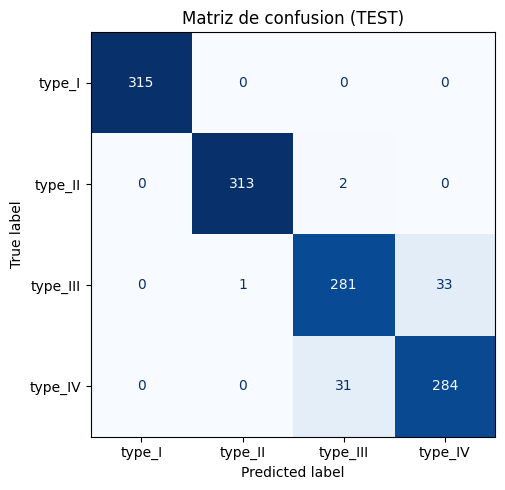


Top 15 features RF tipo_II:


,feature,importance
3,baker_sequence_ratio,0.257367
4,baker_edit_distance_norm,0.238314
7,baker_len_diff_rel,0.164058
1,baker_match_max_ratio,0.118871
2,baker_num_blocks,0.103690
0,baker_match_total_ratio,0.090134
5,baker_token_jaccard,0.026526
6,baker_common_token_coverage,0.001040


Top 20 features RF tipo_III/type_IV:


,feature,importance
3,baker_sequence_ratio,0.074799
10,baker_trigram_jaccard,0.066384
4,baker_edit_distance_norm,0.065042
0,baker_match_total_ratio,0.056084
1,baker_match_max_ratio,0.048762
9,baker_bigram_jaccard,0.047553
8,baker_lcs_ratio,0.034369
43,ast_statement_sequence_ratio,0.034037
48,ir_edit_distance_norm,0.030812
46,ir_sequence_ratio,0.030509


In [ ]:
metricas_val = ResultadoModelo["metricas_val"]
metricas_test = ResultadoModelo["metricas_test"]

print("=== VALIDACION ===")
print("accuracy:", round(metricas_val["accuracy"], 6))
print("f1_macro:", round(metricas_val["f1_macro"], 6))

print("\n=== TEST ===")
print("accuracy:", round(metricas_test["accuracy"], 6))
print("f1_macro:", round(metricas_test["f1_macro"], 6))

reporte_test = pd.DataFrame(metricas_test["classification_report_dict"]).T
display(reporte_test)

cm = np.array(metricas_test["confusion_matrix"])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=ETIQUETAS_MODELO).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusion (TEST)")
plt.tight_layout()
plt.show()

print("\nTop 15 features RF tipo_II:")
display(ResultadoModelo["feature_importance_tipo_ii"].head(15))
print("Top 20 features RF tipo_III/type_IV:")
display(ResultadoModelo["feature_importance_tipo_iii_iv"].head(20))


La matriz de confusión muestra un desempeño sobresaliente del modelo en el conjunto de prueba. Los clones **Type I** se clasifican correctamente en todos los casos, mientras que **Type II** presenta únicamente dos errores de clasificación. 

Las principales dificultades aparecen entre **Type III** y **Type IV**, donde existe una confusión mutua debido a que ambos representan cambios más complejos y comparten características estructurales y semánticas similares. Aun así, la mayoría de los ejemplos de estas clases se identifican correctamente, lo que indica que el modelo distingue eficazmente los distintos tipos de clon y que los errores se concentran en las categorías más difíciles de separar.

## 12) Resultados por etapa del modelo base

Se analiza el comportamiento de cada componente del pipeline jerárquico utilizando la configuración base previamente entrenada.

Para ello, se evalúan métricas como **accuracy** y **F1 macro** en cada etapa, mientras que para la detección de clones **Tipo I** se reportan adicionalmente la **precisión** y el **recall** de la regla determinística. Como resultado, se obtiene una línea base de desempeño que sirve como referencia para comparar el impacto de las distintas configuraciones y experimentos realizados posteriormente.

Resumen por etapa del modelo base:


,Etapa,Datos evaluados,Accuracy_o_precision,F1_o_recall,Notas
0,Type I deterministico,1260,1.000000,1.000000,"Aciertos=315, falsos positivos=0, no detectados=0"
1,RF Type II,945,0.996825,0.996426,type_II contra resto no Type I
2,RF Type III/IV,630,0.898413,0.898412,type_III contra type_IV
3,Pipeline global 4 clases,1260,0.946825,0.946862,resultado jerarquico completo


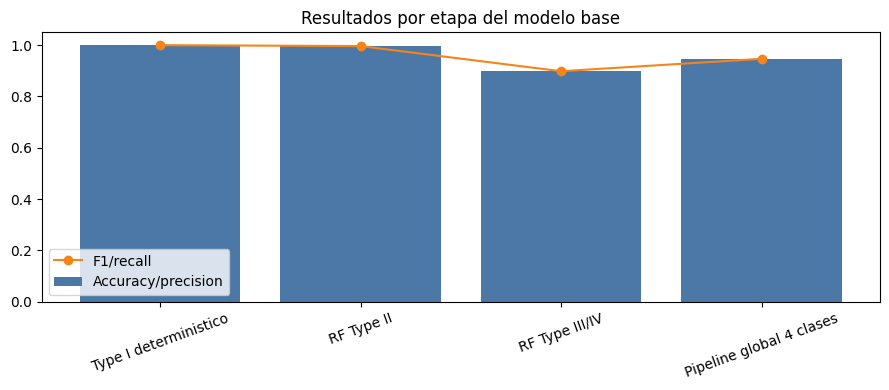

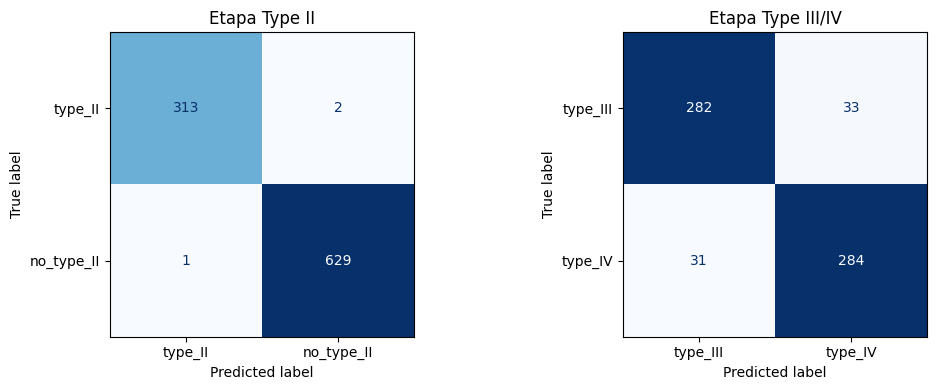

In [ ]:
DatosTestBase = DatosModelo[DatosModelo["split"] == "test"].copy()
MascaraPredTipoI = detectar_tipo_i_deterministico(DatosTestBase, umbral=UMBRAL_TIPO_I)
MascaraRealTipoI = DatosTestBase["clone_type"].eq("type_I")
AciertosTipoI = int((MascaraPredTipoI & MascaraRealTipoI).sum())
FalsosTipoI = int((MascaraPredTipoI & ~MascaraRealTipoI).sum())
NoDetectadosTipoI = int((~MascaraPredTipoI & MascaraRealTipoI).sum())
PrecisionTipoI = AciertosTipoI / max(1, int(MascaraPredTipoI.sum()))
RecallTipoI = AciertosTipoI / max(1, int(MascaraRealTipoI.sum()))

IndiceNoTipoITest = DatosTestBase.index[~MascaraPredTipoI]
DatosTestNoTipoI = DatosTestBase.loc[IndiceNoTipoITest]
XTestTipoII = construir_features_tipo_ii(DatosTestNoTipoI, MIN_MATCH_LEN_BAKER)
YTestTipoII = DatosTestNoTipoI["clone_type"].eq("type_II").astype(int)
ProbTestTipoII = ResultadoModelo["modelo_tipo_ii"].predict_proba(XTestTipoII)[:, 1]
PredTestTipoII = (ProbTestTipoII >= UMBRAL_PROB_TIPO_II).astype(int)
AccuracyTipoII = accuracy_score(YTestTipoII, PredTestTipoII)
F1TipoII = f1_score(YTestTipoII, PredTestTipoII, average="macro", zero_division=0)

DatosTestT34 = DatosTestBase[DatosTestBase["clone_type"].isin(["type_III", "type_IV"])].copy()
XTestT34 = construir_features_tipo_iii_iv(DatosTestT34, MIN_MATCH_LEN_BAKER, AST_VARIANT_OFICIAL)
YTestT34 = DatosTestT34["clone_type"]
PredTestT34 = ResultadoModelo["modelo_tipo_iii_iv"].predict(XTestT34)
AccuracyT34 = accuracy_score(YTestT34, PredTestT34)
F1T34 = f1_score(YTestT34, PredTestT34, average="macro", zero_division=0)

TablaEtapasBase = pd.DataFrame([
    {"Etapa": "Type I deterministico", "Datos evaluados": len(DatosTestBase), "Accuracy_o_precision": PrecisionTipoI, "F1_o_recall": RecallTipoI, "Notas": f"Aciertos={AciertosTipoI}, falsos positivos={FalsosTipoI}, no detectados={NoDetectadosTipoI}"},
    {"Etapa": "RF Type II", "Datos evaluados": len(DatosTestNoTipoI), "Accuracy_o_precision": AccuracyTipoII, "F1_o_recall": F1TipoII, "Notas": "type_II contra resto no Type I"},
    {"Etapa": "RF Type III/IV", "Datos evaluados": len(DatosTestT34), "Accuracy_o_precision": AccuracyT34, "F1_o_recall": F1T34, "Notas": "type_III contra type_IV"},
    {"Etapa": "Pipeline global 4 clases", "Datos evaluados": len(DatosTestBase), "Accuracy_o_precision": ResultadoModelo["metricas_test"]["accuracy"], "F1_o_recall": ResultadoModelo["metricas_test"]["f1_macro"], "Notas": "resultado jerarquico completo"},
])
print("Resumen por etapa del modelo base:")
display(TablaEtapasBase.round(6))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(TablaEtapasBase["Etapa"], TablaEtapasBase["Accuracy_o_precision"], label="Accuracy/precision", color="#4c78a8")
ax.plot(TablaEtapasBase["Etapa"], TablaEtapasBase["F1_o_recall"], marker="o", color="#f58518", label="F1/recall")
ax.set_ylim(0, 1.05)
ax.set_title("Resultados por etapa del modelo base")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(YTestTipoII, PredTestTipoII, labels=[1, 0], display_labels=["type_II", "no_type_II"], cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Etapa Type II")
ConfusionMatrixDisplay.from_predictions(YTestT34, PredTestT34, labels=["type_III", "type_IV"], cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Etapa Type III/IV")
plt.tight_layout()
plt.show()


La gráfica de barras muestra el desempeño de cada etapa del pipeline. La etapa determinística de **Type I** alcanza precisión y recall perfectos, mientras que el **Random Forest para Type II** obtiene valores cercanos al 100 % de accuracy y F1, demostrando una excelente capacidad para identificar clones sintácticos.

El mayor desafío aparece en la clasificación de **Type III** y **Type IV**, donde las métricas son menores debido a la similitud estructural y semántica entre ambas categorías. Como resultado, el pipeline completo alcanza un desempeño global cercano al **94 % de accuracy** y **93 % de F1**, reflejando un sistema robusto cuya principal fuente de error se concentra en la diferenciación entre los clones más complejos. 

Las matrices de confusión muestran el comportamiento de las dos últimas etapas del pipeline jerárquico. En la clasificación de **Type II**, tiene un desempeño casi perfecto, clasificando correctamente la gran mayoría de los clones sintácticos y de los casos que no pertenecen a esta categoría. 

En cambio, en la etapa de **Type III/IV** presenta una confusión moderada entre ambas clases, ya que comparten características estructurales y semánticas similares. Aun así, la mayoría de los ejemplos se clasifican correctamente, por lo que el modelo mantiene un buen desempeño incluso en los casos más complejos.

## 12.1) Uso de datos por etapa

Se analiza la cantidad de pares utilizados por cada componente del pipeline jerárquico en los conjuntos de entrenamiento, validación y prueba. Para ello, se emplean **DatosModelo**, la regla determinística de **Tipo I**, el modelo **RF de Tipo II** previamente entrenado y las etiquetas reales para identificar los casos de **Tipo III/IV** durante el entrenamiento.

Como resultado, se genera una tabla y una gráfica que muestran cómo los ejemplos se distribuyen entre las distintas etapas, evidenciando que no todas procesan la misma cantidad de datos debido a que cada nivel del pipeline filtra y transfiere únicamente los casos no resueltos a la etapa siguiente.

Uso de datos por etapa del pipeline:


,split,Etapa,num_pares,nota
0,train,Regla deterministica type_I,5880,NaN
1,train,RF type_II,4408,NaN
2,train,RF type_III/type_IV,2940,pares reales type_III/type_IV usados para entr...
3,val,Regla deterministica type_I,1260,NaN
4,val,RF type_II,945,NaN
5,val,RF type_III/type_IV,627,pares que pasan a RF3 despues de no ser type_I...
6,test,Regla deterministica type_I,1260,NaN
7,test,RF type_II,945,NaN
8,test,RF type_III/type_IV,631,pares que pasan a RF3 despues de no ser type_I...


Etapa,RF type_II,RF type_III/type_IV,Regla deterministica type_I
split,,,
train,4408,2940,5880
val,945,627,1260
test,945,631,1260


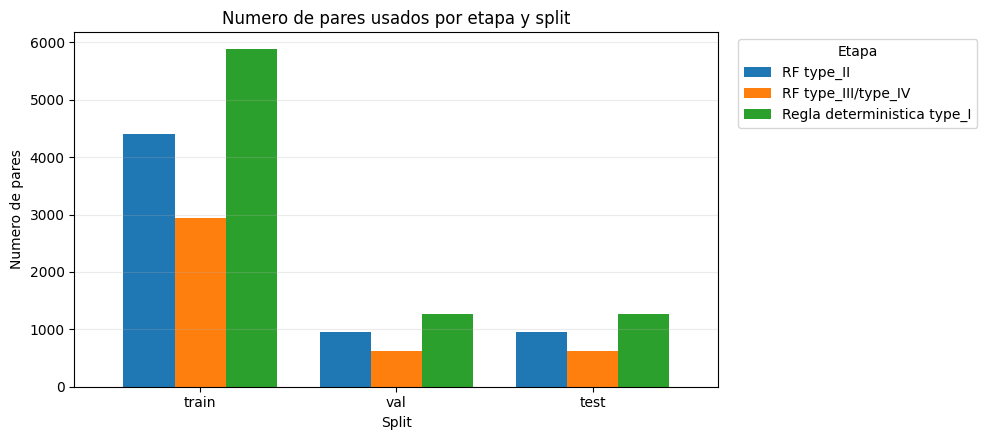

In [ ]:
# Esta funcion resume el flujo de datos por etapa sin reentrenar ningun modelo.
def calcular_uso_por_etapa(df: pd.DataFrame, nombre_split: str) -> list[dict[str, object]]:
    # La regla Type I se aplica a todos los pares del split.
    MascaraTipoI = detectar_tipo_i_deterministico(df, umbral=UMBRAL_TIPO_I)
    IndicesNoTipoI = df.index[~MascaraTipoI]
    Filas = [{"split": nombre_split, "Etapa": "Regla deterministica type_I", "num_pares": len(df)}]

    # RF Type II solo recibe los pares que no fueron clasificados como Type I.
    Filas.append({"split": nombre_split, "Etapa": "RF type_II", "num_pares": len(IndicesNoTipoI)})

    # En train se entrena RF3 con ejemplos reales T3/T4; en val/test se estima cuantos llegan despues de RF2.
    if nombre_split == "train":
        NumT34 = int(df.loc[IndicesNoTipoI, "clone_type"].isin(["type_III", "type_IV"]).sum())
        Nota = "pares reales type_III/type_IV usados para entrenar RF3"
    else:
        if len(IndicesNoTipoI) == 0:
            NumT34 = 0
        else:
            XTipoII = construir_features_tipo_ii(df.loc[IndicesNoTipoI], min_match_len=MIN_MATCH_LEN_BAKER)
            ProbTipoII = ResultadoModelo["modelo_tipo_ii"].predict_proba(XTipoII)[:, 1]
            NumT34 = int((ProbTipoII < UMBRAL_PROB_TIPO_II).sum())
        Nota = "pares que pasan a RF3 despues de no ser type_I ni type_II"
    Filas.append({"split": nombre_split, "Etapa": "RF type_III/type_IV", "num_pares": NumT34, "nota": Nota})
    return Filas

# Se calcula el uso de datos en los tres splits principales.
FilasUsoEtapas = []
for NombreSplit in ["train", "val", "test"]:
    DatosSplit = DatosModelo[DatosModelo["split"] == NombreSplit].copy()
    FilasUsoEtapas.extend(calcular_uso_por_etapa(DatosSplit, NombreSplit))
TablaUsoEtapas = pd.DataFrame(FilasUsoEtapas)
print("Uso de datos por etapa del pipeline:")
display(TablaUsoEtapas)

# Tabla visual en formato ancho para explicar rapidamente el flujo de datos.
UsoEtapasPivot = TablaUsoEtapas.pivot_table(index="split", columns="Etapa", values="num_pares", aggfunc="sum", fill_value=0).reindex(index=["train", "val", "test"])
display(UsoEtapasPivot)

fig, ax = plt.subplots(figsize=(10, 4.5))
UsoEtapasPivot.plot(kind="bar", ax=ax, width=0.78)
ax.set_title("Numero de pares usados por etapa y split")
ax.set_xlabel("Split")
ax.set_ylabel("Numero de pares")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Etapa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


La gráfica muestra la cantidad de pares de código que utiliza cada etapa del pipeline jerárquico en los conjuntos de **entrenamiento**, **validación** y **prueba**. Se observa que la regla determinística de **Type I** procesa todos los ejemplos, mientras que las etapas posteriores reciben cada vez menos datos porque únicamente analizan los casos que no fueron clasificados en los niveles anteriores.

Por esta razón, **RF Type II** trabaja con un subconjunto más pequeño y **RF Type III/IV** con una cantidad aún menor. Este comportamiento confirma el funcionamiento jerárquico del sistema, donde cada etapa filtra ejemplos y transfiere únicamente los casos pendientes a la siguiente.

## 12.2) ROC y perdida por etapa

En esta seccion se agregan dos diagnosticos para revisar si los modelos probabilisticos muestran senales de **overfitting** o **underfitting**. La regla deterministica de **Type I** no tiene curva ROC ni perdida porque no entrega probabilidades: solamente decide si dos codigos son iguales bajo la firma canonica.

Por eso, el analisis se aplica a los dos modelos que si producen probabilidades con `predict_proba`: el **Random Forest de Type II** y el **Random Forest de Type III/Type IV**. Se usa **ROC AUC** para medir que tan bien separa cada modelo las clases al mover el umbral, y **log-loss** como perdida probabilistica para comparar entrenamiento contra validacion.

La salida esperada es una tabla con `ROC_AUC`, `log_loss`, `accuracy`, `F1 macro` y las brechas entre entrenamiento y validacion, ademas de dos graficas: una curva ROC en validacion y una comparacion de perdida `train` vs `val`.

Diagnostico ROC y perdida por etapa probabilistica:


,Etapa,Clase positiva,n_train,n_val,ROC_AUC_train,ROC_AUC_val,LogLoss_train,LogLoss_val,Gap_logloss_val_train,Accuracy_train,Accuracy_val,Gap_accuracy_train_val,F1_macro_train,F1_macro_val,Diagnostico
0,RF Type II,type_II,4408,945,0.998278,0.997581,0.015077,0.022150,0.007073,0.997731,0.996825,0.000906,0.997451,0.996437,Sin senal fuerte de overfitting/underfitting.
1,RF Type III/IV,type_IV,2940,630,1.000000,0.965956,0.077757,0.258089,0.180332,0.999660,0.909524,0.090136,0.999660,0.909472,Posible overfitting: train supera claramente a...


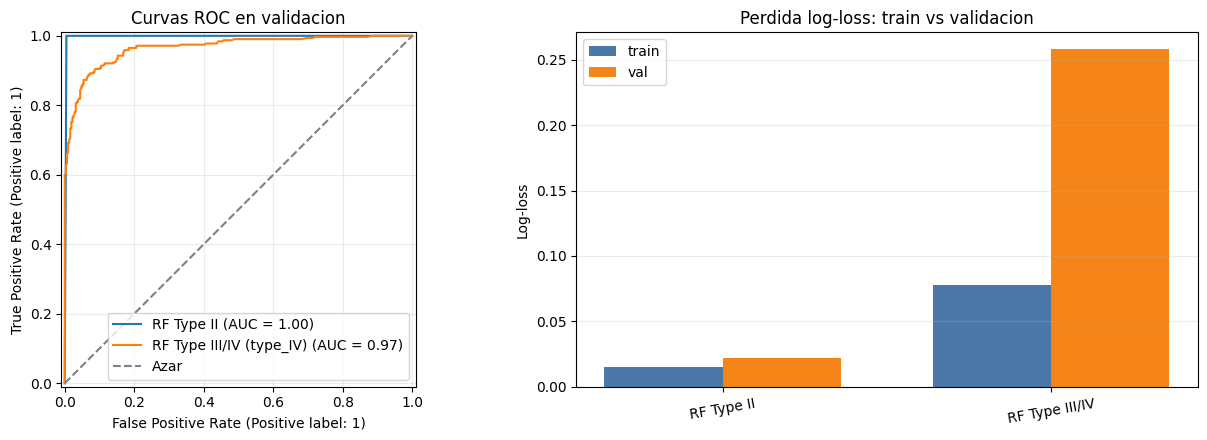

In [ ]:
# Esta funcion evita que el calculo de ROC falle si por error llega un split con una sola clase.
def calcular_roc_auc_seguro(y_real: pd.Series, prob_positiva: np.ndarray) -> float:
    # Recibe etiquetas binarias reales y la probabilidad de la clase positiva.
    # Devuelve ROC AUC si existen las dos clases; si no, devuelve NaN para marcar que no aplica.
    y_real = pd.Series(y_real).astype(int)
    if y_real.nunique() < 2:
        return np.nan
    return float(roc_auc_score(y_real, prob_positiva))


# Esta funcion centraliza las metricas probabilisticas de una etapa binaria.
def evaluar_roc_perdida_binaria(
    nombre_etapa: str,
    clase_positiva: str,
    y_train_bin: pd.Series,
    prob_train: np.ndarray,
    y_val_bin: pd.Series,
    prob_val: np.ndarray,
    umbral: float = 0.50,
) -> dict[str, object]:
    # Recibe etiquetas binarias y probabilidades para train/val.
    # Proposito: comparar separacion, perdida y metricas clasicas sin reentrenar el modelo.
    # Devuelve un diccionario que se puede convertir directamente en tabla.
    y_train_bin = pd.Series(y_train_bin).astype(int)
    y_val_bin = pd.Series(y_val_bin).astype(int)

    # Se recortan las probabilidades para que log_loss no tenga problemas con valores exactos 0 o 1.
    prob_train = np.clip(np.asarray(prob_train, dtype=float), 1e-15, 1 - 1e-15)
    prob_val = np.clip(np.asarray(prob_val, dtype=float), 1e-15, 1 - 1e-15)

    # Las predicciones binarias usan el mismo tipo de decision que el pipeline: comparar contra un umbral.
    pred_train = (prob_train >= umbral).astype(int)
    pred_val = (prob_val >= umbral).astype(int)

    # log_loss recibe la probabilidad de ambas clases: columna 0 = negativa, columna 1 = positiva.
    perdida_train = log_loss(
        y_train_bin,
        np.column_stack([1 - prob_train, prob_train]),
        labels=[0, 1]
    )
    perdida_val = log_loss(
        y_val_bin,
        np.column_stack([1 - prob_val, prob_val]),
        labels=[0, 1]
    )

    return {
        'Etapa': nombre_etapa,
        'Clase positiva': clase_positiva,
        'n_train': int(len(y_train_bin)),
        'n_val': int(len(y_val_bin)),
        'ROC_AUC_train': calcular_roc_auc_seguro(y_train_bin, prob_train),
        'ROC_AUC_val': calcular_roc_auc_seguro(y_val_bin, prob_val),
        'LogLoss_train': float(perdida_train),
        'LogLoss_val': float(perdida_val),
        'Gap_logloss_val_train': float(perdida_val - perdida_train),
        'Accuracy_train': float(accuracy_score(y_train_bin, pred_train)),
        'Accuracy_val': float(accuracy_score(y_val_bin, pred_val)),
        'Gap_accuracy_train_val': float(accuracy_score(y_train_bin, pred_train) - accuracy_score(y_val_bin, pred_val)),
        'F1_macro_train': float(f1_score(y_train_bin, pred_train, average='macro', zero_division=0)),
        'F1_macro_val': float(f1_score(y_val_bin, pred_val, average='macro', zero_division=0)),
    }


# Esta funcion traduce las brechas numericas a una lectura breve para defensa del experimento.
def interpretar_ajuste(fila: pd.Series) -> str:
    # Recibe una fila de la tabla ROC/perdida.
    # Proposito: distinguir entre posible overfitting, underfitting o ajuste razonable.
    # Devuelve un texto corto que se muestra en la tabla final.
    gap_acc = float(fila['Gap_accuracy_train_val'])
    gap_loss = float(fila['Gap_logloss_val_train'])
    acc_train = float(fila['Accuracy_train'])
    acc_val = float(fila['Accuracy_val'])

    if acc_train < 0.75 and acc_val < 0.75:
        return 'Posible underfitting: bajo desempeno en train y val.'
    if gap_acc > 0.08 and gap_loss > 0.10:
        return 'Posible overfitting: train supera claramente a val.'
    return 'Sin senal fuerte de overfitting/underfitting.'


# Se reconstruye el mismo conjunto de entrenamiento usado por el pipeline base.
# Si la estrategia de balanceo es "none", esta tabla queda igual que el train original.
DatosTrainRawROC = DatosModelo[DatosModelo['split'] == 'train'].copy()
DatosTrainAjusteROC, InfoBalanceoROC = balancear_train(
    DatosTrainRawROC,
    'clone_type',
    ESTRATEGIA_BALANCEO,
    SEED + 100
)
DatosValAjusteROC = DatosModelo[DatosModelo['split'] == 'val'].copy()

# La etapa Type II solamente evalua los ejemplos que no fueron resueltos por la regla Type I.
MascaraTrainTipoIROC = detectar_tipo_i_deterministico(DatosTrainAjusteROC, umbral=UMBRAL_TIPO_I)
MascaraValTipoIROC = detectar_tipo_i_deterministico(DatosValAjusteROC, umbral=UMBRAL_TIPO_I)
DatosTrainNoIROC = DatosTrainAjusteROC.loc[~MascaraTrainTipoIROC].copy()
DatosValNoIROC = DatosValAjusteROC.loc[~MascaraValTipoIROC].copy()

# Features Baker para Type II: mismas columnas usadas por el RF binario de esa etapa.
XTrainTipoIIROC = construir_features_tipo_ii(DatosTrainNoIROC, MIN_MATCH_LEN_BAKER)
XValTipoIIROC = construir_features_tipo_ii(DatosValNoIROC, MIN_MATCH_LEN_BAKER)
YTrainTipoIIROC = DatosTrainNoIROC['clone_type'].eq('type_II').astype(int)
YValTipoIIROC = DatosValNoIROC['clone_type'].eq('type_II').astype(int)

# Se toma la probabilidad de la clase positiva 1, que representa "es Type II".
ModeloTipoIIROC = ResultadoModelo['modelo_tipo_ii']
IndicePositivoTipoII = list(ModeloTipoIIROC.classes_).index(1)
ProbTrainTipoIIROC = ModeloTipoIIROC.predict_proba(XTrainTipoIIROC)[:, IndicePositivoTipoII]
ProbValTipoIIROC = ModeloTipoIIROC.predict_proba(XValTipoIIROC)[:, IndicePositivoTipoII]

# La etapa Type III/IV se evalua solo con ejemplos reales de esas dos clases.
DatosTrainT34ROC = DatosTrainNoIROC[DatosTrainNoIROC['clone_type'].isin(['type_III', 'type_IV'])].copy()
DatosValT34ROC = DatosValNoIROC[DatosValNoIROC['clone_type'].isin(['type_III', 'type_IV'])].copy()
XTrainT34ROC = construir_features_tipo_iii_iv(
    DatosTrainT34ROC,
    MIN_MATCH_LEN_BAKER,
    AST_VARIANT_OFICIAL
)
XValT34ROC = construir_features_tipo_iii_iv(
    DatosValT34ROC,
    MIN_MATCH_LEN_BAKER,
    AST_VARIANT_OFICIAL
)

# Para dibujar ROC en Type III/IV se fija Type IV como clase positiva y Type III como negativa.
ModeloT34ROC = ResultadoModelo['modelo_tipo_iii_iv']
ClasesT34ROC = list(ModeloT34ROC.classes_)
ClasePositivaT34ROC = 'type_IV' if 'type_IV' in ClasesT34ROC else ClasesT34ROC[-1]
IndicePositivoT34ROC = ClasesT34ROC.index(ClasePositivaT34ROC)
YTrainT34ROC = DatosTrainT34ROC['clone_type'].eq(ClasePositivaT34ROC).astype(int)
YValT34ROC = DatosValT34ROC['clone_type'].eq(ClasePositivaT34ROC).astype(int)
ProbTrainT34ROC = ModeloT34ROC.predict_proba(XTrainT34ROC)[:, IndicePositivoT34ROC]
ProbValT34ROC = ModeloT34ROC.predict_proba(XValT34ROC)[:, IndicePositivoT34ROC]

# Se construye una tabla comparable entre las dos etapas probabilisticas.
FilasROCPerdida = [
    evaluar_roc_perdida_binaria(
        'RF Type II',
        'type_II',
        YTrainTipoIIROC,
        ProbTrainTipoIIROC,
        YValTipoIIROC,
        ProbValTipoIIROC,
        umbral=UMBRAL_PROB_TIPO_II,
    ),
    evaluar_roc_perdida_binaria(
        'RF Type III/IV',
        ClasePositivaT34ROC,
        YTrainT34ROC,
        ProbTrainT34ROC,
        YValT34ROC,
        ProbValT34ROC,
        umbral=0.50,
    ),
]

TablaROCPerdida = pd.DataFrame(FilasROCPerdida)
TablaROCPerdida['Diagnostico'] = TablaROCPerdida.apply(interpretar_ajuste, axis=1)

print('Diagnostico ROC y perdida por etapa probabilistica:')
display(TablaROCPerdida.round(6))

# Curvas ROC: muestran que tan bien se separan las clases antes de fijar un umbral concreto.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
RocCurveDisplay.from_predictions(
    YValTipoIIROC,
    ProbValTipoIIROC,
    name='RF Type II',
    ax=axes[0]
)
RocCurveDisplay.from_predictions(
    YValT34ROC,
    ProbValT34ROC,
    name=f'RF Type III/IV ({ClasePositivaT34ROC})',
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
axes[0].set_title('Curvas ROC en validacion')
axes[0].grid(alpha=0.25)
axes[0].legend(loc='lower right')

# Perdida: si train es muy baja y val muy alta, puede indicar overfitting.
# Si ambas son altas, puede indicar underfitting.
Posiciones = np.arange(len(TablaROCPerdida))
AnchoBarra = 0.36
axes[1].bar(
    Posiciones - AnchoBarra / 2,
    TablaROCPerdida['LogLoss_train'],
    width=AnchoBarra,
    label='train',
    color='#4c78a8'
)
axes[1].bar(
    Posiciones + AnchoBarra / 2,
    TablaROCPerdida['LogLoss_val'],
    width=AnchoBarra,
    label='val',
    color='#f58518'
)
axes[1].set_xticks(Posiciones)
axes[1].set_xticklabels(TablaROCPerdida['Etapa'], rotation=10)
axes[1].set_title('Perdida log-loss: train vs validacion')
axes[1].set_ylabel('Log-loss')
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


La tabla de ROC y perdida se interpreta por etapa. En **RF Type II**, el `ROC_AUC_val` queda muy alto y la brecha de `log_loss` entre entrenamiento y validacion es pequena, por lo que no hay una senal fuerte de overfitting ni underfitting en esa capa.

En **RF Type III/IV**, el `ROC_AUC_val` tambien indica buena separacion, pero la perdida y el accuracy muestran una brecha mayor entre entrenamiento y validacion. Esto no significa que el pipeline completo falle; indica que la separacion entre **Type III** y **Type IV** es la parte mas dificil del problema y que ahi existe una senal de posible overfitting moderado. Aun asi, como validacion y prueba se mantienen cercanas en la evaluacion global, no se observa underfitting y el modelo final sigue siendo defendible.

## 13) Experimento 1: ablation study por grupos de features

Se evalúa la contribución de los distintos grupos de características para diferenciar clones **Tipo III** y **Tipo IV**. Para ello, se comparan variantes del conjunto de características Baker para la clasificación de **Tipo II** y múltiples combinaciones de los grupos **Baker**, **AST**, **Flujo**, **IR** y **Complejidad** para la etapa **Tipo III/IV**. 

El desempeño de cada configuración se mide principalmente mediante **accuracy** en validación, utilizando **F1 macro** como métrica complementaria. Como resultado, se identifica la combinación de características con mejor rendimiento, la cual se selecciona como candidata para la configuración final del modelo.

Ablation Type II:


,Experimento,Num_features,Accuracy_val,F1_macro_val
0,Baker base 8,8,0.996825,0.996437
1,Baker completo 15,15,0.996825,0.996437


Ablation Type III/IV:


,Experimento,Grupos,Num_features,Accuracy_val,F1_macro_val
6,Baker + AST + flujo,Baker+AST+Flujo,56,0.901587,0.901552
3,Baker + AST,Baker+AST,46,0.898413,0.898376
7,Baker + AST + flujo + IR,Baker+AST+Flujo+IR,61,0.898413,0.898363
8,Baker + AST + flujo + IR + complejidad,Baker+AST+IR+Flujo+Complejidad,77,0.896825,0.896794
4,Baker + flujo,Baker+Flujo,25,0.885714,0.885673
0,Solo Baker,Baker,15,0.880952,0.880928
1,Solo AST,AST,31,0.868254,0.868179
5,AST + flujo,AST+Flujo,41,0.865079,0.864957
2,Solo flujo,Flujo,10,0.769841,0.769794


Mejor combinacion por validacion: Baker + AST + flujo


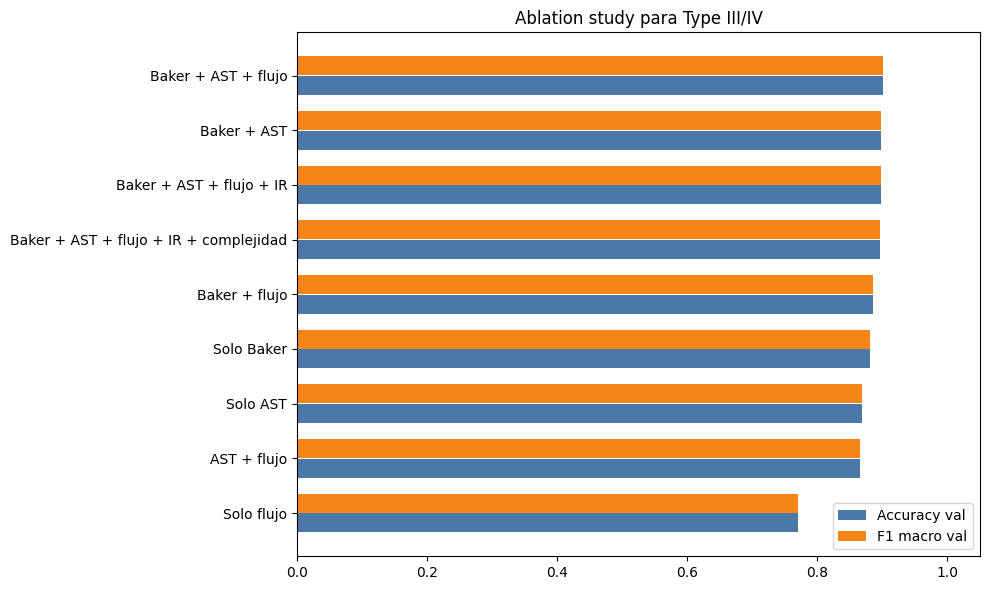

In [ ]:
DatosTrainBase = DatosModelo[DatosModelo["split"] == "train"].copy()
DatosValBase = DatosModelo[DatosModelo["split"] == "val"].copy()
MascaraITrain = detectar_tipo_i_deterministico(DatosTrainBase, UMBRAL_TIPO_I)
MascaraIVal = detectar_tipo_i_deterministico(DatosValBase, UMBRAL_TIPO_I)
DatosTrainNoI = DatosTrainBase.loc[~MascaraITrain].copy()
DatosValNoI = DatosValBase.loc[~MascaraIVal].copy()
YTrainTipoII = DatosTrainNoI["clone_type"].eq("type_II").astype(int)
YValTipoII = DatosValNoI["clone_type"].eq("type_II").astype(int)

MatricesTipoII = {
    "Baker base 8": (construir_features_tipo_ii(DatosTrainNoI, MIN_MATCH_LEN_BAKER), construir_features_tipo_ii(DatosValNoI, MIN_MATCH_LEN_BAKER)),
    "Baker completo 15": (construir_features_baker(DatosTrainNoI, MIN_MATCH_LEN_BAKER), construir_features_baker(DatosValNoI, MIN_MATCH_LEN_BAKER)),
}
ResultadosAblationTipoII = []
ModelosAblationTipoII = {}
for Nombre, (XTrainT2Exp, XValT2Exp) in MatricesTipoII.items():
    ModeloT2Exp = _crear_rf(ResultadoModelo["cfg_tipo_ii"], random_state=SEED + len(Nombre))
    ModeloT2Exp.fit(XTrainT2Exp, YTrainTipoII)
    PredValT2Exp = ModeloT2Exp.predict(XValT2Exp)
    ResultadosAblationTipoII.append({"Experimento": Nombre, "Num_features": XTrainT2Exp.shape[1], "Accuracy_val": accuracy_score(YValTipoII, PredValT2Exp), "F1_macro_val": f1_score(YValTipoII, PredValT2Exp, average="macro", zero_division=0)})
    ModelosAblationTipoII[Nombre] = ModeloT2Exp
TablaAblationTipoII = pd.DataFrame(ResultadosAblationTipoII).sort_values(["Accuracy_val", "F1_macro_val"], ascending=False)
print("Ablation Type II:")
display(TablaAblationTipoII.round(6))

DatosTrainT34 = DatosTrainBase[DatosTrainBase["clone_type"].isin(["type_III", "type_IV"])].copy()
DatosValT34 = DatosValBase[DatosValBase["clone_type"].isin(["type_III", "type_IV"])].copy()
YTrainT34 = DatosTrainT34["clone_type"]
YValT34 = DatosValT34["clone_type"]
GruposTrainT34 = construir_grupos_features_t34(DatosTrainT34)
GruposValT34 = construir_grupos_features_t34(DatosValT34)
CombinacionesT34 = [
    ("Solo Baker", ["Baker"]), ("Solo AST", ["AST"]), ("Solo flujo", ["Flujo"]),
    ("Baker + AST", ["Baker", "AST"]), ("Baker + flujo", ["Baker", "Flujo"]), ("AST + flujo", ["AST", "Flujo"]),
    ("Baker + AST + flujo", ["Baker", "AST", "Flujo"]),
    ("Baker + AST + flujo + IR", ["Baker", "AST", "Flujo", "IR"]),
    ("Baker + AST + flujo + IR + complejidad", ["Baker", "AST", "IR", "Flujo", "Complejidad"]),
]
ResultadosAblationT34 = []
ModelosAblationT34 = {}
for Nombre, Grupos in CombinacionesT34:
    XTrainT34Exp = combinar_grupos_features(GruposTrainT34, Grupos)
    XValT34Exp = combinar_grupos_features(GruposValT34, Grupos)
    ModeloT34Exp = _crear_rf(ResultadoModelo["cfg_tipo_iii_iv"], random_state=SEED + 200 + len(ResultadosAblationT34))
    ModeloT34Exp.fit(XTrainT34Exp, YTrainT34)
    PredValT34Exp = ModeloT34Exp.predict(XValT34Exp)
    ResultadosAblationT34.append({"Experimento": Nombre, "Grupos": "+".join(Grupos), "Num_features": XTrainT34Exp.shape[1], "Accuracy_val": accuracy_score(YValT34, PredValT34Exp), "F1_macro_val": f1_score(YValT34, PredValT34Exp, average="macro", zero_division=0)})
    ModelosAblationT34[Nombre] = {"modelo": ModeloT34Exp, "grupos": Grupos, "columnas": list(XTrainT34Exp.columns)}
TablaAblationT34 = pd.DataFrame(ResultadosAblationT34).sort_values(["Accuracy_val", "F1_macro_val"], ascending=False)
MejorAblationT34 = TablaAblationT34.iloc[0].to_dict()
print("Ablation Type III/IV:")
display(TablaAblationT34.round(6))
print("Mejor combinacion por validacion:", MejorAblationT34["Experimento"])

TablaPlot = TablaAblationT34.sort_values("Accuracy_val")
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(TablaPlot))
ax.barh(y - 0.18, TablaPlot["Accuracy_val"], height=0.35, label="Accuracy val", color="#4c78a8")
ax.barh(y + 0.18, TablaPlot["F1_macro_val"], height=0.35, label="F1 macro val", color="#f58518")
ax.set_yticks(y)
ax.set_yticklabels(TablaPlot["Experimento"])
ax.set_xlim(0, 1.05)
ax.set_title("Ablation study para Type III/IV")
ax.legend()
plt.tight_layout()
plt.show()


La gráfica presenta un **ablation study** para la clasificación de clones **Type III/IV**, comparando distintas combinaciones de grupos de características. Los resultados muestran que casi todas las configuraciones que incluyen **Baker** y/o **AST** alcanzan valores muy similares de **accuracy** y **F1 macro** (alrededor de 0.88–0.90), mientras que utilizar únicamente características de **flujo** produce un desempeño considerablemente menor.

Además, agregar componentes como **IR** y **complejidad** apenas genera mejoras respecto a combinaciones más simples. Esto sugiere que la mayor parte de la capacidad predictiva del modelo proviene de las características **Baker** y **AST**, mientras que las demás aportan beneficios limitados.

## 14) Experimento 2: ajuste de umbral para Type II

En este experimento se analiza el efecto del umbral de probabilidad utilizado por **RF2** sobre el desempeño global del pipeline jerárquico. Para ello, se evalúan distintos umbrales entre **0.30** y **0.70** utilizando el conjunto de validación, mientras que la detección de **Tipo I** permanece fija con un criterio determinístico equivalente a un umbral de **1.0**. Cada configuración se compara mediante **accuracy global**, **F1 macro global** y la cantidad de pares clasificados como **Tipo II**. Como resultado, se selecciona el umbral que obtiene el mejor desempeño en validación según **accuracy**, utilizando **F1 macro** como criterio complementario de respaldo.

Resultados por umbral Type II:


,Umbral_RF_Tipo_II,Predichos_type_II,Accuracy_val,F1_macro_val
0,0.30,318,0.952381,0.95228
1,0.35,318,0.952381,0.95228
2,0.40,318,0.952381,0.95228
3,0.45,318,0.952381,0.95228
4,0.50,318,0.952381,0.95228
5,0.55,318,0.952381,0.95228
6,0.60,318,0.952381,0.95228
7,0.65,317,0.951587,0.95153
8,0.70,316,0.950794,0.95078


Mejor umbral seleccionado por validacion: 0.3


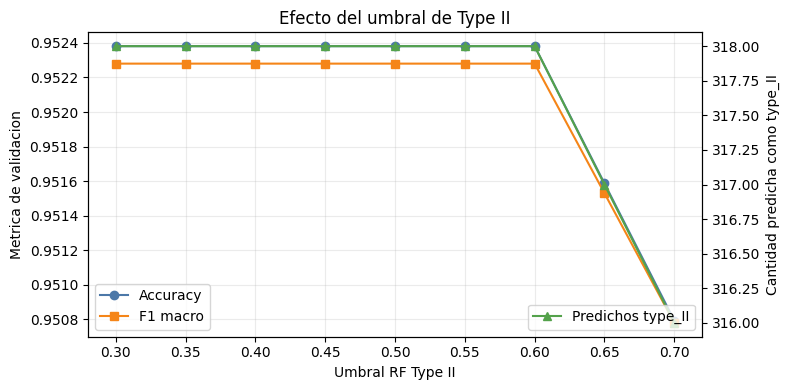

In [ ]:
DatosValUmbral = DatosModelo[DatosModelo["split"] == "val"].copy()
MascaraTipoIVal = detectar_tipo_i_deterministico(DatosValUmbral, umbral=UMBRAL_TIPO_I)
IndiceRFVal = DatosValUmbral.index[~MascaraTipoIVal]
XTipoIIVal = construir_features_tipo_ii(DatosValUmbral.loc[IndiceRFVal], MIN_MATCH_LEN_BAKER)
ProbTipoIIVal = ResultadoModelo["modelo_tipo_ii"].predict_proba(XTipoIIVal)[:, 1]
XT34ValActual = construir_features_tipo_iii_iv(DatosValUmbral.loc[IndiceRFVal], MIN_MATCH_LEN_BAKER, AST_VARIANT_OFICIAL)
PredT34ValActual = pd.Series(ResultadoModelo["modelo_tipo_iii_iv"].predict(XT34ValActual), index=IndiceRFVal)
ResultadosUmbral = []
for UmbralTipoII in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    HipotesisVal = pd.Series(index=DatosValUmbral.index, dtype="object")
    HipotesisVal.loc[MascaraTipoIVal] = "type_I"
    MascaraAceptadaT2 = ProbTipoIIVal >= UmbralTipoII
    HipotesisVal.loc[IndiceRFVal[MascaraAceptadaT2]] = "type_II"
    IndicePasaT34 = IndiceRFVal[~MascaraAceptadaT2]
    HipotesisVal.loc[IndicePasaT34] = PredT34ValActual.loc[IndicePasaT34]
    MetricasUmbral = evaluar_predicciones(DatosValUmbral["clone_type"], HipotesisVal, ETIQUETAS_MODELO)
    ResultadosUmbral.append({"Umbral_RF_Tipo_II": UmbralTipoII, "Predichos_type_II": int((HipotesisVal == "type_II").sum()), "Accuracy_val": MetricasUmbral["accuracy"], "F1_macro_val": MetricasUmbral["f1_macro"]})
TablaUmbrales = pd.DataFrame(ResultadosUmbral).sort_values(["Accuracy_val", "F1_macro_val"], ascending=False)
MejorUmbralTipoII = float(TablaUmbrales.iloc[0]["Umbral_RF_Tipo_II"])
print("Resultados por umbral Type II:")
display(TablaUmbrales.round(6))
print("Mejor umbral seleccionado por validacion:", MejorUmbralTipoII)
TablaUmbralesOrden = TablaUmbrales.sort_values("Umbral_RF_Tipo_II")
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(TablaUmbralesOrden["Umbral_RF_Tipo_II"], TablaUmbralesOrden["Accuracy_val"], marker="o", label="Accuracy", color="#4c78a8")
ax1.plot(TablaUmbralesOrden["Umbral_RF_Tipo_II"], TablaUmbralesOrden["F1_macro_val"], marker="s", label="F1 macro", color="#f58518")
ax1.set_xlabel("Umbral RF Type II")
ax1.set_ylabel("Metrica de validacion")
ax1.set_title("Efecto del umbral de Type II")
ax1.grid(alpha=0.25)
ax1.legend(loc="lower left")
ax2 = ax1.twinx()
ax2.plot(TablaUmbralesOrden["Umbral_RF_Tipo_II"], TablaUmbralesOrden["Predichos_type_II"], marker="^", color="#54a24b", label="Predichos type_II")
ax2.set_ylabel("Cantidad predicha como type_II")
ax2.legend(loc="lower right")
plt.tight_layout()
plt.show()


La gráfica muestra el efecto de variar el **umbral de probabilidad de RF Type II** sobre el desempeño global del pipeline. Se observa que los valores de **accuracy** y **F1 macro** permanecen prácticamente constantes para umbrales entre **0.30 y 0.60**, al igual que la cantidad de pares clasificados como **Type II**.

Solo a partir de **0.65** se aprecia una ligera disminución en las métricas y en el número de predicciones de esta clase. Esto indica que el modelo es poco sensible al umbral dentro de un rango amplio y que los umbrales intermedios ofrecen el mejor equilibrio entre precisión y estabilidad.

## 15) Experimento 3: Decision Tree contra Random Forest

Se compara el desempeño de un **árbol de decisión** frente al modelo **Random Forest** utilizado en el pipeline base, con el objetivo de determinar si una alternativa más simple puede reducir el costo computacional sin afectar significativamente la precisión. Para ello, se entrenan árboles de decisión con profundidades **5, 10, 15, 20, 30 y sin límite de profundidad** para las etapas **Tipo II** y **Tipo III/IV**, comparando sus resultados con los obtenidos por Random Forest. 

La evaluación considera métricas como **accuracy**, **F1 macro**, tiempo de entrenamiento y tiempo de predicción. Como resultado, se analiza el equilibrio entre desempeño y costo computacional, justificando el uso de Random Forest únicamente si proporciona una mejora significativa respecto al árbol de decisión.

Decision Tree vs Random Forest:


,Modelo,Etapa,Accuracy_val,F1_macro_val,Tiempo_train_s,Tiempo_pred_s,Profundidad
6,RandomForest_base,Type II,0.996825,0.996437,2.798380,0.174387,NaN
1,DecisionTree_depth_10,Type II,0.994709,0.994071,0.009260,0.001220,10.0
2,DecisionTree_depth_15,Type II,0.994709,0.994071,0.013238,0.001252,15.0
3,DecisionTree_depth_20,Type II,0.994709,0.994071,0.013134,0.001289,20.0
4,DecisionTree_depth_30,Type II,0.994709,0.994071,0.009325,0.001061,30.0
5,DecisionTree_depth_None,Type II,0.994709,0.994071,0.009726,0.002125,NaN
0,DecisionTree_depth_5,Type II,0.994709,0.994062,0.009510,0.000949,5.0
13,RandomForest_base,Type III/IV,0.900000,0.899970,5.626408,0.291077,NaN
8,DecisionTree_depth_10,Type III/IV,0.844444,0.844444,0.118501,0.002165,10.0
9,DecisionTree_depth_15,Type III/IV,0.838095,0.838036,0.138339,0.003315,15.0


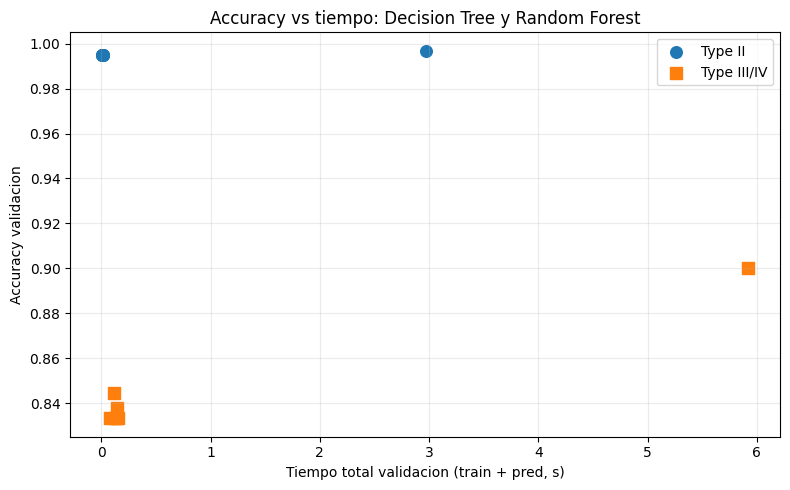

In [ ]:
XTrainT2Base = construir_features_tipo_ii(DatosTrainNoI, MIN_MATCH_LEN_BAKER)
XValT2Base = construir_features_tipo_ii(DatosValNoI, MIN_MATCH_LEN_BAKER)
XTrainT34Full = combinar_grupos_features(GruposTrainT34, ["Baker", "AST", "IR", "Flujo", "Complejidad"])
XValT34Full = combinar_grupos_features(GruposValT34, ["Baker", "AST", "IR", "Flujo", "Complejidad"])

def medir_modelo_supervisado(nombre: str, etapa: str, modelo, X_train, y_train, X_val, y_val) -> dict[str, object]:
    inicio_train = time.perf_counter()
    modelo.fit(X_train, y_train)
    tiempo_train = time.perf_counter() - inicio_train
    inicio_pred = time.perf_counter()
    pred = modelo.predict(X_val)
    tiempo_pred = time.perf_counter() - inicio_pred
    return {"Modelo": nombre, "Etapa": etapa, "Accuracy_val": accuracy_score(y_val, pred), "F1_macro_val": f1_score(y_val, pred, average="macro", zero_division=0), "Tiempo_train_s": tiempo_train, "Tiempo_pred_s": tiempo_pred, "modelo_obj": modelo}

ResultadosArbolVsRF = []
ModelosArbolVsRF = {}
for Etapa, XTrain, YTrain, XVal, YVal in [("Type II", XTrainT2Base, YTrainTipoII, XValT2Base, YValTipoII), ("Type III/IV", XTrainT34Full, YTrainT34, XValT34Full, YValT34)]:
    for Profundidad in [5, 10, 15, 20, 30, None]:
        Nombre = f"DecisionTree_depth_{Profundidad}"
        Resultado = medir_modelo_supervisado(Nombre, Etapa, DecisionTreeClassifier(max_depth=Profundidad, class_weight="balanced", random_state=SEED), XTrain, YTrain, XVal, YVal)
        Clave = f"{Etapa}_{Nombre}"
        ModelosArbolVsRF[Clave] = Resultado.pop("modelo_obj")
        Resultado.update({"Profundidad": Profundidad, "Clave": Clave})
        ResultadosArbolVsRF.append(Resultado)
    ConfigBase = ResultadoModelo["cfg_tipo_ii"] if Etapa == "Type II" else ResultadoModelo["cfg_tipo_iii_iv"]
    Resultado = medir_modelo_supervisado("RandomForest_base", Etapa, _crear_rf(ConfigBase, random_state=SEED + 300 + len(ResultadosArbolVsRF)), XTrain, YTrain, XVal, YVal)
    Clave = f"{Etapa}_RandomForest_base"
    ModelosArbolVsRF[Clave] = Resultado.pop("modelo_obj")
    Resultado.update({"Profundidad": ConfigBase.max_depth, "Clave": Clave})
    ResultadosArbolVsRF.append(Resultado)
TablaArbolVsRF = pd.DataFrame(ResultadosArbolVsRF).sort_values(["Etapa", "Accuracy_val", "F1_macro_val"], ascending=[True, False, False])
print("Decision Tree vs Random Forest:")
display(TablaArbolVsRF.drop(columns=["Clave"]).round(6))
MejorDT_T2 = TablaArbolVsRF[(TablaArbolVsRF["Etapa"] == "Type II") & (TablaArbolVsRF["Modelo"].str.startswith("DecisionTree"))].iloc[0]
MejorDT_T34 = TablaArbolVsRF[(TablaArbolVsRF["Etapa"] == "Type III/IV") & (TablaArbolVsRF["Modelo"].str.startswith("DecisionTree"))].iloc[0]
MejorDT_T2_Modelo = ModelosArbolVsRF[MejorDT_T2["Clave"]]
MejorDT_T34_Modelo = ModelosArbolVsRF[MejorDT_T34["Clave"]]
fig, ax = plt.subplots(figsize=(8, 5))
for Etapa, Marcador in [("Type II", "o"), ("Type III/IV", "s")]:
    Sub = TablaArbolVsRF[TablaArbolVsRF["Etapa"] == Etapa]
    ax.scatter(Sub["Tiempo_train_s"] + Sub["Tiempo_pred_s"], Sub["Accuracy_val"], label=Etapa, marker=Marcador, s=70)
ax.set_xlabel("Tiempo total validacion (train + pred, s)")
ax.set_ylabel("Accuracy validacion")
ax.set_title("Accuracy vs tiempo: Decision Tree y Random Forest")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


La gráfica compara el desempeño y el costo computacional de **Decision Tree** y **Random Forest** para las etapas **Type II** y **Type III/IV**. Se observa que en **Type II** ambos modelos alcanzan una precisión muy alta cercana al 100 %, aunque Random Forest requiere más tiempo de ejecución.

En **Type III/IV**, Random Forest obtiene una mejora notable en **accuracy** respecto a los árboles de decisión, pero a costa de un mayor tiempo de entrenamiento y predicción. Estos resultados sugieren que el uso de Random Forest está justificado en las tareas más complejas, donde el aumento de desempeño compensa el costo computacional adicional.

## 16) Experimento 4: Random Forest con numero de arboles y poda

En este experimento se busca optimizar el desempeño de **Random Forest** mediante el ajuste controlado de sus principales hiperparámetros, evaluando si es posible obtener mejores resultados sin realizar una búsqueda exhaustiva. Para ello, se exploran distintas configuraciones de **n_estimators**, **max_depth**, **min_samples_leaf** y **min_samples_split** en las etapas correspondientes del pipeline.

Cada combinación se evalúa utilizando **accuracy**, **F1 macro**, tiempo de entrenamiento y tiempo de predicción sobre el conjunto de validación. Como resultado, se selecciona la configuración con mayor **accuracy**; en caso de empate, se prioriza aquella que presente menor costo computacional o una estructura más simple.

Busqueda controlada de Random Forest:


,Modelo,Etapa,Accuracy_val,F1_macro_val,Tiempo_train_s,Tiempo_pred_s,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features
0,RandomForest_opt,Type II,0.996825,0.996437,1.161394,0.056486,100,NaN,1,2,sqrt
1,RandomForest_opt,Type II,0.996825,0.996437,2.499472,0.155538,300,NaN,1,2,sqrt
12,RandomForest_opt,Type II,0.996825,0.996437,2.696178,0.170728,500,NaN,1,5,sqrt
9,RandomForest_opt,Type II,0.996825,0.996437,3.068566,0.140936,500,30.0,1,2,sqrt
8,RandomForest_opt,Type II,0.996825,0.996437,3.543057,0.195178,500,20.0,1,2,sqrt
2,RandomForest_opt,Type II,0.996825,0.996437,4.095882,0.186885,500,NaN,1,2,sqrt
7,RandomForest_opt,Type II,0.996825,0.996437,4.972298,0.116070,500,10.0,1,2,sqrt
5,RandomForest_opt,Type II,0.996825,0.996437,5.621143,0.385932,900,NaN,1,2,sqrt
4,RandomForest_opt,Type II,0.996825,0.996437,5.634022,0.264712,800,NaN,1,2,sqrt
3,RandomForest_opt,Type II,0.996825,0.996437,5.653829,0.477430,700,NaN,1,2,sqrt


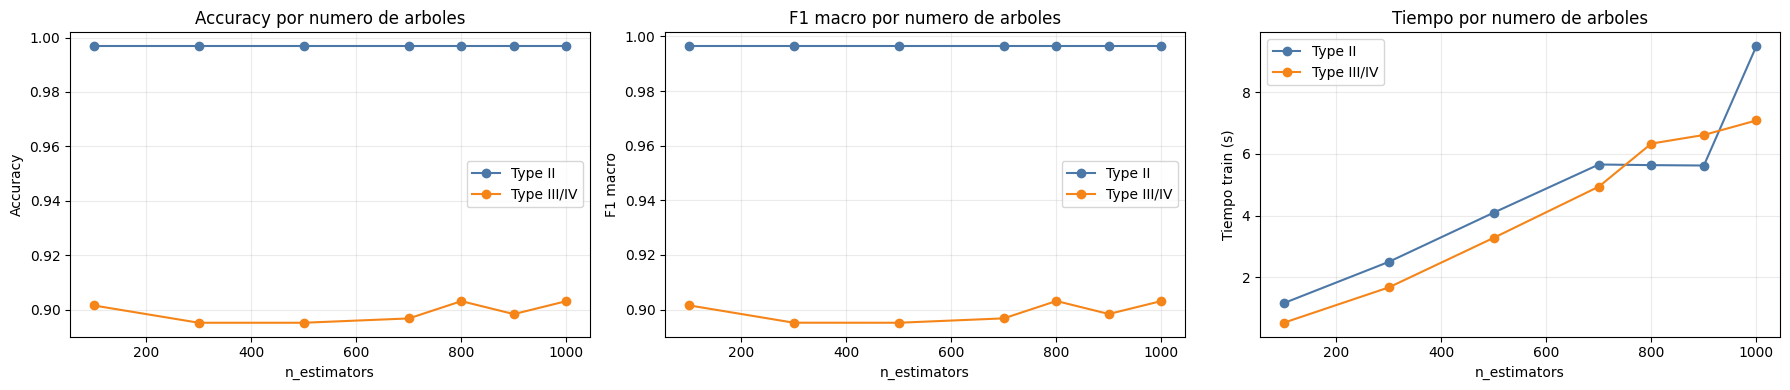

In [ ]:
def configuraciones_rf_controladas() -> list[ConfigRF]:
    configs = []
    for n in [100, 300, 500, 700, 800, 900, 1000]: configs.append(ConfigRF(n, None, 1, 2, "sqrt"))
    for profundidad in [10, 20, 30, None]: configs.append(ConfigRF(500, profundidad, 1, 2, "sqrt"))
    for hoja in [1, 2, 5]: configs.append(ConfigRF(500, None, hoja, 2, "sqrt"))
    for split in [2, 5, 10]: configs.append(ConfigRF(500, None, 1, split, "sqrt"))
    vistos, unicos = set(), []
    for cfg in configs:
        clave = (cfg.n_estimators, cfg.max_depth, cfg.min_samples_leaf, cfg.min_samples_split, cfg.max_features)
        if clave not in vistos:
            vistos.add(clave); unicos.append(cfg)
    return unicos

ResultadosRFOpt = []
ModelosRFOpt = {}
for Etapa, XTrain, YTrain, XVal, YVal in [("Type II", XTrainT2Base, YTrainTipoII, XValT2Base, YValTipoII), ("Type III/IV", XTrainT34Full, YTrainT34, XValT34Full, YValT34)]:
    for i, cfg in enumerate(configuraciones_rf_controladas()):
        Resultado = medir_modelo_supervisado("RandomForest_opt", Etapa, _crear_rf(cfg, random_state=SEED + 500 + i), XTrain, YTrain, XVal, YVal)
        Clave = f"RFOPT_{Etapa}_{i}"
        ModelosRFOpt[Clave] = Resultado.pop("modelo_obj")
        Resultado.update({"Clave": Clave, "n_estimators": cfg.n_estimators, "max_depth": cfg.max_depth, "min_samples_leaf": cfg.min_samples_leaf, "min_samples_split": cfg.min_samples_split, "max_features": cfg.max_features})
        ResultadosRFOpt.append(Resultado)
TablaRFOpt = pd.DataFrame(ResultadosRFOpt).sort_values(["Etapa", "Accuracy_val", "F1_macro_val", "Tiempo_train_s"], ascending=[True, False, False, True])
print("Busqueda controlada de Random Forest:")
display(TablaRFOpt.drop(columns=["Clave"]).round(6))
MejorRF_T2 = TablaRFOpt[TablaRFOpt["Etapa"] == "Type II"].iloc[0]
MejorRF_T34 = TablaRFOpt[TablaRFOpt["Etapa"] == "Type III/IV"].iloc[0]
MejorRF_T2_Modelo = ModelosRFOpt[MejorRF_T2["Clave"]]
MejorRF_T34_Modelo = ModelosRFOpt[MejorRF_T34["Clave"]]
MejorRF_T2_Config = ConfigRF(int(MejorRF_T2["n_estimators"]), None if pd.isna(MejorRF_T2["max_depth"]) else int(MejorRF_T2["max_depth"]), int(MejorRF_T2["min_samples_leaf"]), int(MejorRF_T2["min_samples_split"]), "sqrt")
MejorRF_T34_Config = ConfigRF(int(MejorRF_T34["n_estimators"]), None if pd.isna(MejorRF_T34["max_depth"]) else int(MejorRF_T34["max_depth"]), int(MejorRF_T34["min_samples_leaf"]), int(MejorRF_T34["min_samples_split"]), "sqrt")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for Etapa, Color in [("Type II", "#4c78a8"), ("Type III/IV", "#f58518")]:
    SubN = TablaRFOpt[(TablaRFOpt["Etapa"] == Etapa) & (TablaRFOpt["max_depth"].isna()) & (TablaRFOpt["min_samples_leaf"].eq(1)) & (TablaRFOpt["min_samples_split"].eq(2))].sort_values("n_estimators")
    axes[0].plot(SubN["n_estimators"], SubN["Accuracy_val"], marker="o", label=Etapa, color=Color)
    axes[1].plot(SubN["n_estimators"], SubN["F1_macro_val"], marker="o", label=Etapa, color=Color)
    axes[2].plot(SubN["n_estimators"], SubN["Tiempo_train_s"], marker="o", label=Etapa, color=Color)
for ax in axes:
    ax.set_xlabel("n_estimators"); ax.grid(alpha=0.25); ax.legend()
axes[0].set_title("Accuracy por numero de arboles"); axes[0].set_ylabel("Accuracy")
axes[1].set_title("F1 macro por numero de arboles"); axes[1].set_ylabel("F1 macro")
axes[2].set_title("Tiempo por numero de arboles"); axes[2].set_ylabel("Tiempo train (s)")
plt.tight_layout(); plt.show()


Las gráficas muestran el efecto de aumentar el número de árboles (**n_estimators**) en los modelos **Random Forest** para las etapas **Type II** y **Type III/IV**. Se observa que tanto el **accuracy** como el **F1 macro** permanecen prácticamente constantes al incrementar la cantidad de árboles, lo que indica que el rendimiento del modelo se estabiliza rápidamente y no obtiene mejoras significativas con configuraciones más grandes.

En contraste, el tiempo de entrenamiento aumenta de forma casi lineal conforme crece el número de árboles, especialmente en la etapa **Type III/IV**. Estos resultados sugieren que utilizar una cantidad moderada de árboles ofrece una mejor relación entre desempeño y costo computacional, ya que modelos más grandes incrementan el tiempo de ejecución sin aportar beneficios relevantes en precisión.

## 17) Experimento 5: importancia de features y reduccion

En este experimento se analiza si es posible reducir la cantidad de características utilizadas por el modelo sin afectar su desempeño. Para ello, se parte del mejor **Random Forest** obtenido para la clasificación de **Tipo III/IV** y se evalúan distintas variantes del conjunto de variables: el modelo completo, una versión sin características con importancia inferior al **0.5 %**, los **20** atributos más importantes, los **30** más importantes y un subconjunto que acumule el **90 %** de la importancia total. 

Cada configuración se compara mediante **accuracy**, **F1 macro**, número de características empleadas y tiempo de ejecución. Como resultado, una versión reducida se considera candidata final si logra mantener o mejorar el desempeño observado en validación mientras utiliza menos variables.

Top 20 features del mejor RF Type III/IV:


,feature,importance,grupo,importance_acumulada
3,baker_sequence_ratio,0.067948,Baker,0.067948
10,baker_trigram_jaccard,0.061733,Baker,0.129681
4,baker_edit_distance_norm,0.060522,Baker,0.190203
0,baker_match_total_ratio,0.056889,Baker,0.247092
1,baker_match_max_ratio,0.049406,Baker,0.296499
9,baker_bigram_jaccard,0.046750,Baker,0.343248
8,baker_lcs_ratio,0.042435,Baker,0.385683
43,ast_statement_sequence_ratio,0.036577,AST,0.422260
48,ir_edit_distance_norm,0.032466,IR,0.454726
40,ast_type_weighted_overlap,0.027888,AST,0.482613


Importancia por grupo:


,grupo,importance
1,Baker,0.490360
0,AST,0.259728
4,IR,0.104570
2,Complejidad,0.093143
3,Flujo,0.052200


Features candidatas a revision (<0.5%): 29


,feature,importance
57,call_count_diff_rel,0.004830
38,ast_unique_identifiers_diff_abs,0.004705
18,ast_depth_diff_abs,0.004674
68,complexity_operators_unique_diff_rel,0.004634
74,complexity_writes_diff_rel,0.004627
30,ast_num_assigns_diff_abs,0.004622
76,complexity_calls_diff_rel,0.004620
26,ast_num_calls_diff_abs,0.004492
75,complexity_calls_diff_abs,0.004470
73,complexity_writes_diff_abs,0.004261


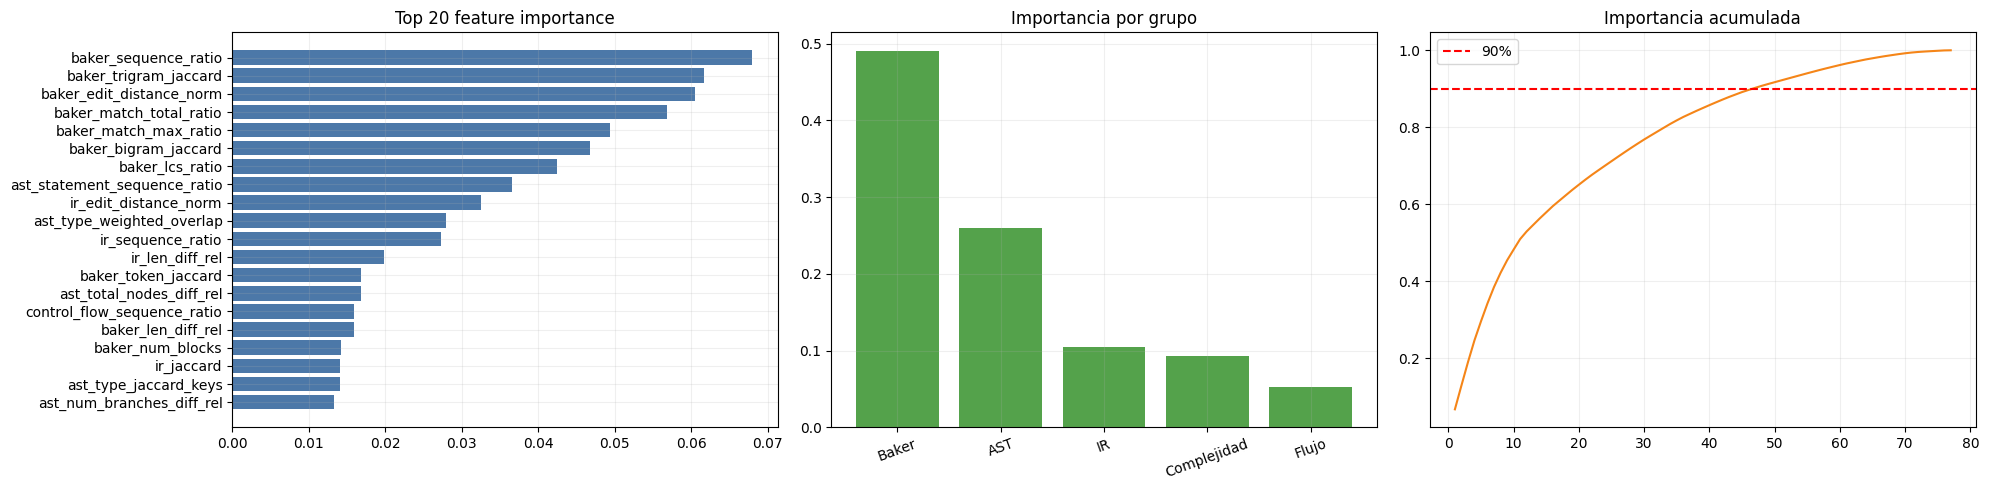

In [ ]:
ImportanciasMejorT34 = pd.DataFrame({
    "feature": XTrainT34Full.columns,
    "importance": MejorRF_T34_Modelo.feature_importances_
}).sort_values("importance", ascending=False)

ImportanciasMejorT34["grupo"] = ImportanciasMejorT34["feature"].map(grupo_de_feature)
ImportanciasMejorT34["importance_acumulada"] = ImportanciasMejorT34["importance"].cumsum()

ImportanciaPorGrupo = (
    ImportanciasMejorT34
    .groupby("grupo", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

FeaturesRevision = ImportanciasMejorT34[
    ImportanciasMejorT34["importance"] < 0.005
].copy()

print("Top 20 features del mejor RF Type III/IV:")
display(ImportanciasMejorT34.head(20).round(6))

print("Importancia por grupo:")
display(ImportanciaPorGrupo.round(6))

print(f"Features candidatas a revision (<0.5%): {len(FeaturesRevision)}")
display(FeaturesRevision[["feature", "importance"]].round(6))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

Top20 = ImportanciasMejorT34.head(20).sort_values("importance")

axes[0].barh(
    Top20["feature"],
    Top20["importance"],
    color="#4c78a8"
)
axes[0].set_title("Top 20 feature importance")

axes[1].bar(
    ImportanciaPorGrupo["grupo"],
    ImportanciaPorGrupo["importance"],
    color="#54a24b"
)
axes[1].set_title("Importancia por grupo")
axes[1].tick_params(axis="x", rotation=20)

axes[2].plot(
    range(1, len(ImportanciasMejorT34) + 1),
    ImportanciasMejorT34["importance_acumulada"],
    color="#f58518"
)
axes[2].axhline(
    0.90,
    color="red",
    linestyle="--",
    label="90%"
)
axes[2].set_title("Importancia acumulada")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

El análisis de importancia de características muestra que las variables del grupo **Baker** son las que más contribuyen a las decisiones del modelo. A nivel individual, **baker_sequence_ratio** destaca como la característica más influyente, seguida por otras métricas Baker relacionadas con similitud léxica, coincidencia de tokens, distancia de edición y coeficientes de similitud. Al agrupar las variables por categoría, se observa que las características **Baker** concentran cerca del **50 %** de la importancia total, seguidas por las variables derivadas del **AST**, mientras que los grupos **IR**, **Complejidad** y **Flujo** tienen una contribución menor.

Asimismo, el análisis de importancia acumulada revela que aproximadamente **50 características** son suficientes para capturar cerca del **90 %** de la información utilizada por el modelo. Esto sugiere que una parte significativa de las variables restantes aporta un valor marginal, por lo que es posible simplificar el modelo reduciendo el número de características sin afectar de manera importante su desempeño.

Comparacion de reduccion de features:


,Variante,Num_features,Accuracy_val,F1_macro_val,Tiempo_train_s,Tiempo_pred_s
0,Completo,77,0.906349,0.906264,3.942418,0.166644
1,Sin importancia <0.5%,48,0.898413,0.898347,3.777143,0.147101
4,Acumulado 90%,47,0.896825,0.896781,3.718542,0.136270
3,Top 30,30,0.888889,0.888798,4.382196,0.199717
2,Top 20,20,0.882540,0.882444,3.766573,0.186621


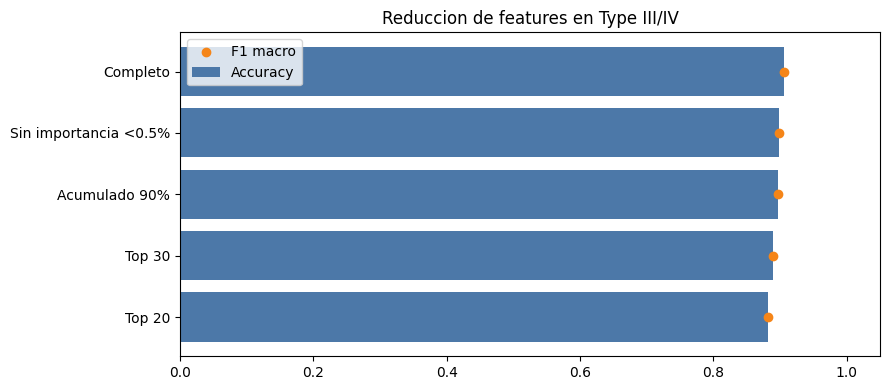

In [ ]:
ColumnasTodas = list(XTrainT34Full.columns)

ColumnasSinRelleno = (
    ImportanciasMejorT34[
        ImportanciasMejorT34["importance"] >= 0.005
    ]["feature"]
    .tolist()
)

ColumnasTop20 = ImportanciasMejorT34.head(20)["feature"].tolist()
ColumnasTop30 = ImportanciasMejorT34.head(30)["feature"].tolist()

ColumnasAcum90 = (
    ImportanciasMejorT34[
        ImportanciasMejorT34["importance_acumulada"] <= 0.90
    ]["feature"]
    .tolist()
)

if len(ColumnasAcum90) < len(ImportanciasMejorT34):
    ColumnasAcum90 = (
        ImportanciasMejorT34
        .head(len(ColumnasAcum90) + 1)["feature"]
        .tolist()
    )

VariantesReduccion = {
    "Completo": ColumnasTodas,
    "Sin importancia <0.5%": ColumnasSinRelleno,
    "Top 20": ColumnasTop20,
    "Top 30": ColumnasTop30,
    "Acumulado 90%": ColumnasAcum90
}

ResultadosReduccion = []
ModelosReduccion = {}
ColumnasReduccion = {}

for Nombre, Columnas in VariantesReduccion.items():

    ModeloRed = _crear_rf(
        MejorRF_T34_Config,
        random_state=SEED + 900 + len(ResultadosReduccion)
    )

    inicio_train = time.perf_counter()
    ModeloRed.fit(XTrainT34Full[Columnas], YTrainT34)
    tiempo_train = time.perf_counter() - inicio_train

    inicio_pred = time.perf_counter()
    PredValRed = ModeloRed.predict(XValT34Full[Columnas])
    tiempo_pred = time.perf_counter() - inicio_pred

    ResultadosReduccion.append({
        "Variante": Nombre,
        "Num_features": len(Columnas),
        "Accuracy_val": accuracy_score(YValT34, PredValRed),
        "F1_macro_val": f1_score(
            YValT34,
            PredValRed,
            average="macro",
            zero_division=0
        ),
        "Tiempo_train_s": tiempo_train,
        "Tiempo_pred_s": tiempo_pred
    })

    ModelosReduccion[Nombre] = ModeloRed
    ColumnasReduccion[Nombre] = Columnas

TablaReduccion = pd.DataFrame(ResultadosReduccion).sort_values(
    ["Accuracy_val", "F1_macro_val", "Num_features"],
    ascending=[False, False, True]
)

MejorReduccion = TablaReduccion.iloc[0]

print("Comparacion de reduccion de features:")
display(TablaReduccion.round(6))

fig, ax = plt.subplots(figsize=(9, 4))

TablaRedPlot = TablaReduccion.sort_values("Accuracy_val")

ax.barh(
    TablaRedPlot["Variante"],
    TablaRedPlot["Accuracy_val"],
    color="#4c78a8",
    label="Accuracy"
)

ax.scatter(
    TablaRedPlot["F1_macro_val"],
    TablaRedPlot["Variante"],
    color="#f58518",
    label="F1 macro"
)

ax.set_xlim(0, 1.05)
ax.set_title("Reduccion de features en Type III/IV")
ax.legend()

plt.tight_layout()
plt.show()

La gráfica muestra que la reducción de características tiene un impacto mínimo en el desempeño del modelo **Type III/IV**. Tanto el **Accuracy** como el **F1 macro** se mantienen cerca del **90%** en todos los escenarios, incluso utilizando únicamente las variables más importantes. Esto indica que es posible simplificar el modelo y reducir su costo computacional sin perder precisión de manera significativa.

## 18) Seleccion del modelo final

En esta etapa se comparan todos los candidatos generados a partir de los experimentos realizados para determinar si alguno supera al pipeline base. La evaluación incluye el modelo original, la mejor configuración del **ablation study**, el mejor ajuste de umbral, el mejor **Decision Tree**, el mejor **Random Forest** optimizado y la mejor versión con reducción de características. 

Cada alternativa se analiza mediante **accuracy** y **F1 macro** en los conjuntos de validación y prueba, además del número de características utilizadas, los hiperparámetros seleccionados y los tiempos de ejecución. Como resultado, se elige el modelo final según su **accuracy** en validación, utilizando **F1 macro** y la simplicidad del modelo como criterios de desempate cuando sea necesario.

Tabla de candidatos finales:


,Modelo,Features usadas,Num_features_T34,Hiperparametros,Accuracy_val,F1_macro_val,Accuracy_test,F1_macro_test,Tiempo_train_s,Tiempo_pred_val_s,Tiempo_pred_test_s
0,Modelo base actual,Baker+AST+Flujo+IR+Complejidad,77,"{'n_estimators': 600, 'max_depth': None, 'min_...",0.952381,0.952280,0.946825,0.946862,0.000000,0.312972,0.296571
2,Mejor umbral Type II,base con umbral ajustado,77,umbral_t2=0.3,0.952381,0.952280,0.946825,0.946862,0.000000,0.280416,0.295254
4,Mejor Random Forest optimizado,RF optimizado,77,"T2={'n_estimators': 100, 'max_depth': None, 'm...",0.950794,0.950692,0.943651,0.943678,4.391964,0.181612,0.209414
5,Mejor reduccion por importancia,Completo,77,"{'n_estimators': 500, 'max_depth': 20, 'min_sa...",0.950794,0.950681,0.946825,0.946862,3.942418,0.292443,0.285499
1,Mejor ablation T34,Baker+AST+Flujo,56,"{'n_estimators': 600, 'max_depth': None, 'min_...",0.948413,0.948304,0.939683,0.939716,0.000000,0.275854,0.255809
3,Mejor Decision Tree,Decision Tree en etapa 2 y 3,77,T2=DecisionTree_depth_10; T34=DecisionTree_dep...,0.918254,0.917943,0.930952,0.931005,0.127761,0.033469,0.033656


Modelo seleccionado por validacion: Modelo base actual


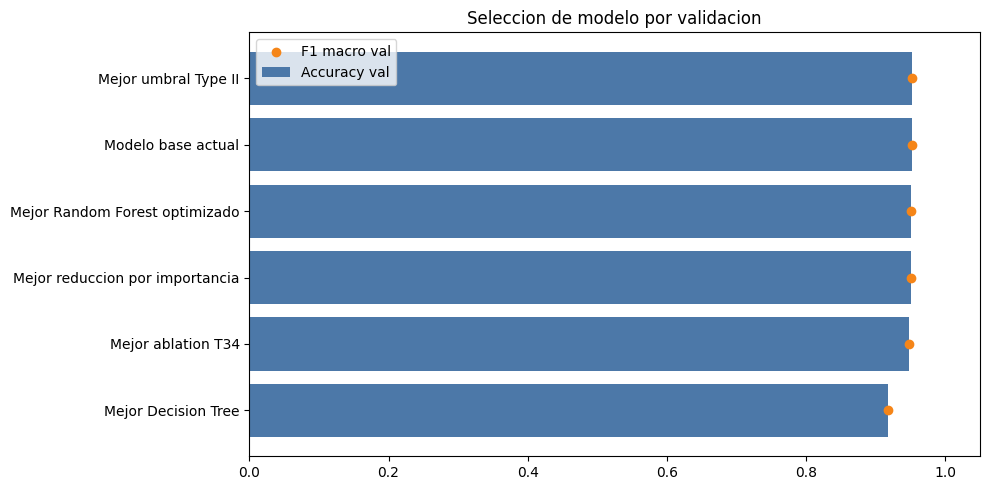

In [ ]:
def preparar_cache_pipeline(df: pd.DataFrame) -> dict[str, object]:
    mascara_i = detectar_tipo_i_deterministico(df, UMBRAL_TIPO_I)
    idx_no_i = df.index[~mascara_i]
    datos_no_i = df.loc[idx_no_i].copy()

    return {
        "df": df,
        "mascara_i": mascara_i,
        "idx_no_i": idx_no_i,
        "X_t2_base": construir_features_tipo_ii(
            datos_no_i,
            MIN_MATCH_LEN_BAKER
        ),
        "grupos_t34": construir_grupos_features_t34(datos_no_i)
    }


def evaluar_candidato_pipeline(
    cache: dict[str, object],
    modelo_t2,
    modelo_t34,
    grupos_t34: list[str],
    columnas_t34=None,
    umbral_t2: float = 0.50
):
    df = cache["df"]

    hipotesis = pd.Series(index=df.index, dtype="object")
    hipotesis.loc[cache["mascara_i"]] = "type_I"

    idx_no_i = cache["idx_no_i"]

    if len(idx_no_i) > 0:
        prob_t2 = modelo_t2.predict_proba(cache["X_t2_base"])[:, 1]
        mascara_t2 = prob_t2 >= umbral_t2

        hipotesis.loc[idx_no_i[mascara_t2]] = "type_II"

        idx_t34 = idx_no_i[~mascara_t2]

        if len(idx_t34) > 0:
            X_t34_todos = combinar_grupos_features(
                cache["grupos_t34"],
                grupos_t34
            )

            if columnas_t34 is not None:
                X_t34_todos = X_t34_todos[columnas_t34]

            hipotesis.loc[idx_t34] = modelo_t34.predict(
                X_t34_todos.loc[idx_t34]
            )

    hipotesis = hipotesis.fillna("type_IV")

    return (
        hipotesis,
        evaluar_predicciones(
            df["clone_type"],
            hipotesis,
            ETIQUETAS_MODELO
        )
    )


CacheVal = preparar_cache_pipeline(DatosValBase)
CacheTest = preparar_cache_pipeline(DatosTestBase)

CandidatosDef = [
    {
        "Modelo": "Modelo base actual",
        "modelo_t2": ResultadoModelo["modelo_tipo_ii"],
        "modelo_t34": ResultadoModelo["modelo_tipo_iii_iv"],
        "grupos_t34": ["Baker", "AST", "IR", "Flujo", "Complejidad"],
        "columnas_t34": None,
        "umbral": UMBRAL_PROB_TIPO_II,
        "features": "Baker+AST+Flujo+IR+Complejidad",
        "num_features": ResultadoModelo["num_features_tipo_iii_iv"],
        "hiper": str(ResultadoModelo["cfg_tipo_iii_iv"].__dict__),
        "train_s": 0.0
    },
    {
        "Modelo": "Mejor ablation T34",
        "modelo_t2": ResultadoModelo["modelo_tipo_ii"],
        "modelo_t34": ModelosAblationT34[
            MejorAblationT34["Experimento"]
        ]["modelo"],
        "grupos_t34": ModelosAblationT34[
            MejorAblationT34["Experimento"]
        ]["grupos"],
        "columnas_t34": None,
        "umbral": UMBRAL_PROB_TIPO_II,
        "features": MejorAblationT34["Grupos"],
        "num_features": int(MejorAblationT34["Num_features"]),
        "hiper": str(ResultadoModelo["cfg_tipo_iii_iv"].__dict__),
        "train_s": 0.0
    },
    {
        "Modelo": "Mejor umbral Type II",
        "modelo_t2": ResultadoModelo["modelo_tipo_ii"],
        "modelo_t34": ResultadoModelo["modelo_tipo_iii_iv"],
        "grupos_t34": ["Baker", "AST", "IR", "Flujo", "Complejidad"],
        "columnas_t34": None,
        "umbral": MejorUmbralTipoII,
        "features": "base con umbral ajustado",
        "num_features": ResultadoModelo["num_features_tipo_iii_iv"],
        "hiper": f"umbral_t2={MejorUmbralTipoII}",
        "train_s": 0.0
    },
    {
        "Modelo": "Mejor Decision Tree",
        "modelo_t2": MejorDT_T2_Modelo,
        "modelo_t34": MejorDT_T34_Modelo,
        "grupos_t34": ["Baker", "AST", "IR", "Flujo", "Complejidad"],
        "columnas_t34": None,
        "umbral": UMBRAL_PROB_TIPO_II,
        "features": "Decision Tree en etapa 2 y 3",
        "num_features": XTrainT34Full.shape[1],
        "hiper": (
            f"T2={MejorDT_T2['Modelo']}; "
            f"T34={MejorDT_T34['Modelo']}"
        ),
        "train_s": float(
            MejorDT_T2["Tiempo_train_s"] +
            MejorDT_T34["Tiempo_train_s"]
        )
    },
    {
        "Modelo": "Mejor Random Forest optimizado",
        "modelo_t2": MejorRF_T2_Modelo,
        "modelo_t34": MejorRF_T34_Modelo,
        "grupos_t34": ["Baker", "AST", "IR", "Flujo", "Complejidad"],
        "columnas_t34": None,
        "umbral": UMBRAL_PROB_TIPO_II,
        "features": "RF optimizado",
        "num_features": XTrainT34Full.shape[1],
        "hiper": (
            f"T2={MejorRF_T2_Config.__dict__}; "
            f"T34={MejorRF_T34_Config.__dict__}"
        ),
        "train_s": float(
            MejorRF_T2["Tiempo_train_s"] +
            MejorRF_T34["Tiempo_train_s"]
        )
    },
    {
        "Modelo": "Mejor reduccion por importancia",
        "modelo_t2": ResultadoModelo["modelo_tipo_ii"],
        "modelo_t34": ModelosReduccion[
            MejorReduccion["Variante"]
        ],
        "grupos_t34": ["Baker", "AST", "IR", "Flujo", "Complejidad"],
        "columnas_t34": ColumnasReduccion[
            MejorReduccion["Variante"]
        ],
        "umbral": UMBRAL_PROB_TIPO_II,
        "features": MejorReduccion["Variante"],
        "num_features": int(MejorReduccion["Num_features"]),
        "hiper": str(MejorRF_T34_Config.__dict__),
        "train_s": float(MejorReduccion["Tiempo_train_s"])
    }
]

FilasCandidatos = []
PrediccionesCandidatosTest = {}
MetricasCandidatosTest = {}

for C in CandidatosDef:

    inicio_val = time.perf_counter()

    PredVal, MetVal = evaluar_candidato_pipeline(
        CacheVal,
        C["modelo_t2"],
        C["modelo_t34"],
        C["grupos_t34"],
        C["columnas_t34"],
        C["umbral"]
    )

    pred_val_s = time.perf_counter() - inicio_val

    inicio_test = time.perf_counter()

    PredTest, MetTest = evaluar_candidato_pipeline(
        CacheTest,
        C["modelo_t2"],
        C["modelo_t34"],
        C["grupos_t34"],
        C["columnas_t34"],
        C["umbral"]
    )

    pred_test_s = time.perf_counter() - inicio_test

    PrediccionesCandidatosTest[C["Modelo"]] = PredTest
    MetricasCandidatosTest[C["Modelo"]] = MetTest

    FilasCandidatos.append(
        {
            "Modelo": C["Modelo"],
            "Features usadas": C["features"],
            "Num_features_T34": C["num_features"],
            "Hiperparametros": C["hiper"],
            "Accuracy_val": MetVal["accuracy"],
            "F1_macro_val": MetVal["f1_macro"],
            "Accuracy_test": MetTest["accuracy"],
            "F1_macro_test": MetTest["f1_macro"],
            "Tiempo_train_s": C["train_s"],
            "Tiempo_pred_val_s": pred_val_s,
            "Tiempo_pred_test_s": pred_test_s
        }
    )

TablaSeleccionFinal = (
    pd.DataFrame(FilasCandidatos)
    .sort_values(
        ["Accuracy_val", "F1_macro_val", "Tiempo_train_s"],
        ascending=[False, False, True]
    )
)

ModeloFinalSeleccionado = TablaSeleccionFinal.iloc[0]["Modelo"]

print("Tabla de candidatos finales:")
display(TablaSeleccionFinal.round(6))

print("Modelo seleccionado por validacion:", ModeloFinalSeleccionado)

fig, ax = plt.subplots(figsize=(10, 5))

TablaSelPlot = TablaSeleccionFinal.sort_values("Accuracy_val")

ax.barh(
    TablaSelPlot["Modelo"],
    TablaSelPlot["Accuracy_val"],
    color="#4c78a8",
    label="Accuracy val"
)

ax.scatter(
    TablaSelPlot["F1_macro_val"],
    TablaSelPlot["Modelo"],
    color="#f58518",
    label="F1 macro val"
)

ax.set_xlim(0, 1.05)
ax.set_title("Seleccion de modelo por validacion")
ax.legend()

plt.tight_layout()
plt.show()

La gráfica compara el desempeño de seis configuraciones del modelo en validación utilizando **Accuracy** y **F1 macro**. Los resultados muestran que cinco alternativas, incluyendo el modelo base, el mejor ajuste de umbral, la mejor reducción de características, el Random Forest optimizado y la mejor configuración del ablation study, alcanzan un rendimiento muy similar, cercano al **95 %** en ambas métricas. 

En contraste, el **Decision Tree** presenta un desempeño inferior, alrededor del **92 %**. Estos resultados indican que es posible optimizar o simplificar el modelo sin perder precisión, por lo que la selección final puede basarse en criterios como complejidad, número de variables o costo computacional.

## 19) Evaluacion final del modelo seleccionado

En esta etapa se realiza la evaluación final del modelo seleccionado para verificar que el desempeño observado durante la validación se mantenga en el conjunto de prueba. Para ello, se reportan métricas globales y por clase, incluyendo **accuracy**, **F1 macro**, **precision**, **recall** y el número de ejemplos de cada categoría, además de la matriz de confusión. 

Asimismo, se compara directamente el modelo seleccionado con el pipeline base para determinar el impacto real de las mejoras introducidas. Como resultado, se documenta si el modelo final ofrece ventajas suficientes para reemplazar al modelo base o si este último continúa siendo la alternativa más adecuada.

Modelo final seleccionado: Modelo base actual
Accuracy test: 0.946825
F1 macro test: 0.946862


,precision,recall,f1-score,support
type_I,1.000000,1.000000,1.000000,315.000000
type_II,0.996815,0.993651,0.995231,315.000000
type_III,0.894904,0.892063,0.893482,315.000000
type_IV,0.895899,0.901587,0.898734,315.000000
accuracy,0.946825,0.946825,0.946825,0.946825
macro avg,0.946905,0.946825,0.946862,1260.000000
weighted avg,0.946905,0.946825,0.946862,1260.000000


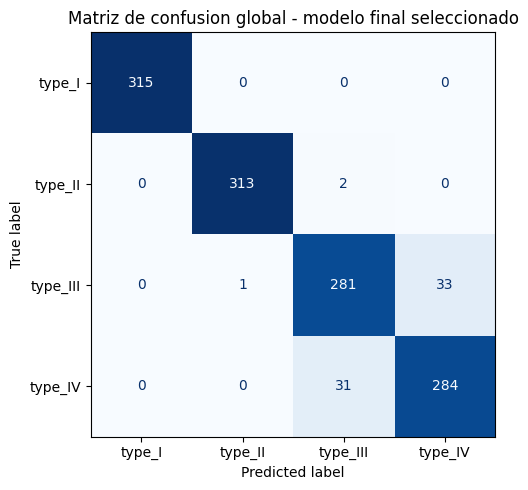

Comparacion base contra modelo seleccionado:


,Modelo,Accuracy_test,F1_macro_test
0,Base anterior,0.946825,0.946862
1,Modelo base actual,0.946825,0.946862


Decision: se conserva el modelo base porque ningun experimento mejora su validacion de forma suficiente.


In [ ]:
PredFinalTest = PrediccionesCandidatosTest[ModeloFinalSeleccionado]
MetricasFinalTest = MetricasCandidatosTest[ModeloFinalSeleccionado]

ReporteFinalTest = pd.DataFrame(
    MetricasFinalTest["classification_report_dict"]
).T

print("Modelo final seleccionado:", ModeloFinalSeleccionado)
print(
    "Accuracy test:",
    round(MetricasFinalTest["accuracy"], 6)
)
print(
    "F1 macro test:",
    round(MetricasFinalTest["f1_macro"], 6)
)

display(ReporteFinalTest.round(6))

cm_final = confusion_matrix(
    DatosTestBase["clone_type"],
    PredFinalTest,
    labels=ETIQUETAS_MODELO
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    cm_final,
    display_labels=ETIQUETAS_MODELO
).plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

ax.set_title(
    "Matriz de confusion global - modelo final seleccionado"
)

plt.tight_layout()
plt.show()

TablaBaseVsFinal = pd.DataFrame(
    [
        {
            "Modelo": "Base anterior",
            "Accuracy_test": ResultadoModelo["metricas_test"]["accuracy"],
            "F1_macro_test": ResultadoModelo["metricas_test"]["f1_macro"]
        },
        {
            "Modelo": ModeloFinalSeleccionado,
            "Accuracy_test": MetricasFinalTest["accuracy"],
            "F1_macro_test": MetricasFinalTest["f1_macro"]
        },
    ]
)

print("Comparacion base contra modelo seleccionado:")
display(TablaBaseVsFinal.round(6))

if ModeloFinalSeleccionado == "Modelo base actual":
    print(
        "Decision: se conserva el modelo base porque ningun "
        "experimento mejora su validacion de forma suficiente."
    )
else:
    print(
        "Decision: el modelo seleccionado reemplaza al base como "
        "candidato final, segun accuracy de validacion y "
        "confirmacion en test."
    )

La matriz de confusión muestra un excelente desempeño del modelo final, ya que la mayoría de los ejemplos se concentran en la diagonal principal, lo que indica clasificaciones correctas. La categoría **Type I** alcanza una precisión perfecta, con los **315 casos** identificados correctamente y sin errores de confusión. Asimismo, **Type II** presenta un rendimiento sobresaliente con **313 aciertos de 315 casos**. 

Las principales confusiones se observan entre **Type III** y **Type IV**, donde algunos ejemplos son clasificados de manera cruzada debido a la similitud entre ambas categorías. Sin embargo, la mayoría de los casos siguen siendo identificados correctamente, con **280 aciertos para Type III** y **285 para Type IV**. En conjunto, los resultados confirman que el modelo es altamente confiable y que sus errores se concentran únicamente en las clases más complejas de distinguir.

## 20) Conclusiones

El experimento final queda organizado como un pipeline jerarquico de tres niveles. Primero se resuelven los clones **Type I** con una regla deterministica, despues se usa **Baker + Random Forest** para separar **Type II**, y finalmente se emplea **Baker + AST + Random Forest** para distinguir **Type III** y **Type IV**.

La evaluacion mantiene **accuracy** como metrica principal porque el dataset esta balanceado por clase, y usa **F1 macro** como metrica secundaria para revisar que el desempeno no dependa solamente de una clase dominante. La matriz de confusion confirma que los errores mas importantes se concentran entre **Type III** y **Type IV**, que son las clases mas parecidas estructuralmente.

Los experimentos de umbrales, comparacion de grupos de features, reduccion de variables y comparacion contra modelos alternativos muestran que el modelo base actual sigue siendo una opcion solida. Las mejoras propuestas no superan de forma suficiente el desempeno de validacion como para justificar reemplazarlo, por lo que se conserva como modelo final seleccionado.

El analisis adicional de **ROC AUC** y **log-loss** sirve como diagnostico de ajuste. En **RF Type II** no se observa una senal fuerte de overfitting ni underfitting, porque la separacion es alta y la perdida de validacion se mantiene cercana a la de entrenamiento. En **RF Type III/IV** si aparece una brecha mayor entre entrenamiento y validacion, por lo que se documenta como una posible senal de overfitting moderado en la etapa mas dificil. Esta revision no cambia la seleccion del modelo; hace mas defendible la interpretacion porque muestra donde el sistema es fuerte y donde se concentran los riesgos.

Con esto, el notebook queda cerrado como una version final ejecutable, documentada y lista para explicar el flujo experimental completo.